# Using Cahn Hilliard free energy model to measure cell repartition in a tissue

# Cell type clusters, GT vs Predicitons

##  AnnData from MERFISH mouse cortex CSV 


In [1]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy.sparse import csr_matrix
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

CSV_PATH = "/home/asalmona/Documents/Ricci/data/MERFISH_LUNA_small_cortex/MERFISH_mouse_cortex_test.csv"
CELL_SECTION = "mouse2_slice219"
sample_id = "mouse2_sample5"
N_GENE_COLS = 254


## after import

In [2]:
# Load CSV (first column is an index)
df = pd.read_csv(CSV_PATH, index_col=0)
print(df.shape)
print("First columns:", list(df.columns[:5]))
print("Last columns:", list(df.columns[-10:]))

# Filter one slice
df = df[df["cell_section"] == CELL_SECTION].copy()
print("After filtering:", df.shape)

# Transcriptome matrix = first N_GENE_COLS columns
gene_cols = list(df.columns[:N_GENE_COLS])

# Build X / var
X = csr_matrix(df[gene_cols].to_numpy(dtype=np.float32))
var = pd.DataFrame(index=gene_cols)

# Build obs with metadata + cell types
obs_cols = [
    "cell_name",
    "coord_X",
    "coord_Y",
    "class",
    "cell_class",
    "mouse",
    "sample_id",
    "cell_section",
]
obs = df[obs_cols].copy()

# Make sure types are categorical for plotting
for c in ["class", "cell_class", "mouse", "sample_id", "cell_section"]:
    obs[c] = pd.Categorical(obs[c])

# Use cell_name as obs_names if unique; otherwise keep the CSV index
if obs["cell_name"].is_unique:
    obs.index = obs["cell_name"].astype(str)

adata = ad.AnnData(X=X, obs=obs, var=var)
adata.obsm["spatial"] = obs[["coord_X", "coord_Y"]].to_numpy(dtype=np.float32)

adata

(118036, 262)
First columns: ['1700022I11Rik', '1810046K07Rik', '5031425F14Rik', '5730522E02Rik', 'Acta2']
Last columns: ['Penk', 'Gad1', 'cell_name', 'coord_X', 'coord_Y', 'class', 'cell_class', 'mouse', 'sample_id', 'cell_section']
After filtering: (3560, 262)


AnnData object with n_obs × n_vars = 3560 × 254
    obs: 'cell_name', 'coord_X', 'coord_Y', 'class', 'cell_class', 'mouse', 'sample_id', 'cell_section'
    obsm: 'spatial'

In [3]:
# Quick sanity checks
print(adata)
print("X shape:", adata.X.shape)
print("# genes kept:", adata.n_vars)
print("cell_section counts:\n", adata.obs["cell_section"].value_counts())

# Example: plot cell types in space (optional)
# import scanpy as sc
# sc.pl.spatial(adata, color="cell_class", spot_size=10, frameon=False)


AnnData object with n_obs × n_vars = 3560 × 254
    obs: 'cell_name', 'coord_X', 'coord_Y', 'class', 'cell_class', 'mouse', 'sample_id', 'cell_section'
    obsm: 'spatial'
X shape: (3560, 254)
# genes kept: 254
cell_section counts:
 cell_section
mouse2_slice219    3560
Name: count, dtype: int64


## plots

/tmp/ipykernel_179950/2702015068.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color="Acta2", spot_size=20, frameon=False, cmap="Reds")


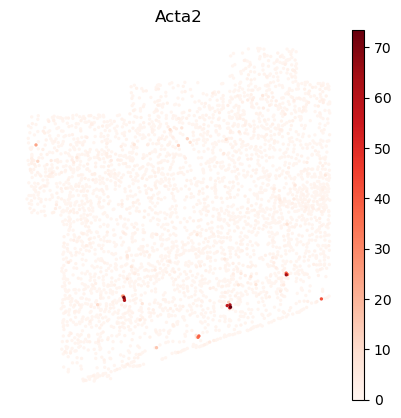

In [4]:
sc.pl.spatial(adata, color="Acta2", spot_size=20, frameon=False, cmap="Reds")

In [5]:
from spatial_correlation import spatial_gene_distance_grid

gene_names = adata.var_names.tolist()

top_genes_dict = {'000': 0}
minmax_gene, minmax_gene_var = '000', 0

for gene in gene_names:
    dist = spatial_gene_distance_grid(adata, gene, 1000)
    var = dist.variance
    if len(top_genes_dict) < 12:
        top_genes_dict[gene] = var
        if var < minmax_gene_var:
            minmax_gene, minmax_gene_var = gene, var
    else:
        if var > minmax_gene_var:
            top_genes_dict.pop(minmax_gene)
            top_genes_dict[gene] = var
            # gets the new minmax gene from the top 10
            minmax_gene = min(top_genes_dict, key=top_genes_dict.get)
            minmax_gene_var = top_genes_dict[minmax_gene]

top_genes = list(top_genes_dict.keys())

In [6]:
print(top_genes)

['Adamts4', 'Cux2', 'Igfbp5', 'Ptprt', 'Sema5a', 'Slc30a3', 'Sox10', 'Spon1', 'Sulf2', 'Syt6', 'Unc5b', 'Unc5d']


Adamts4 with variance 14.238651718252187
Cux2 with variance 12.55747175081459
Igfbp5 with variance 37.48993646268487
Ptprt with variance 18.040254286964064
Sema5a with variance 8.945350853475418
Slc30a3 with variance 20.90795230865518
Sox10 with variance 18.84262258284331
Spon1 with variance 13.88338389930907
Sulf2 with variance 36.54328484807353
Syt6 with variance 10.71748598582443
Unc5b with variance 11.05593483847715
Unc5d with variance 1.599944945129264


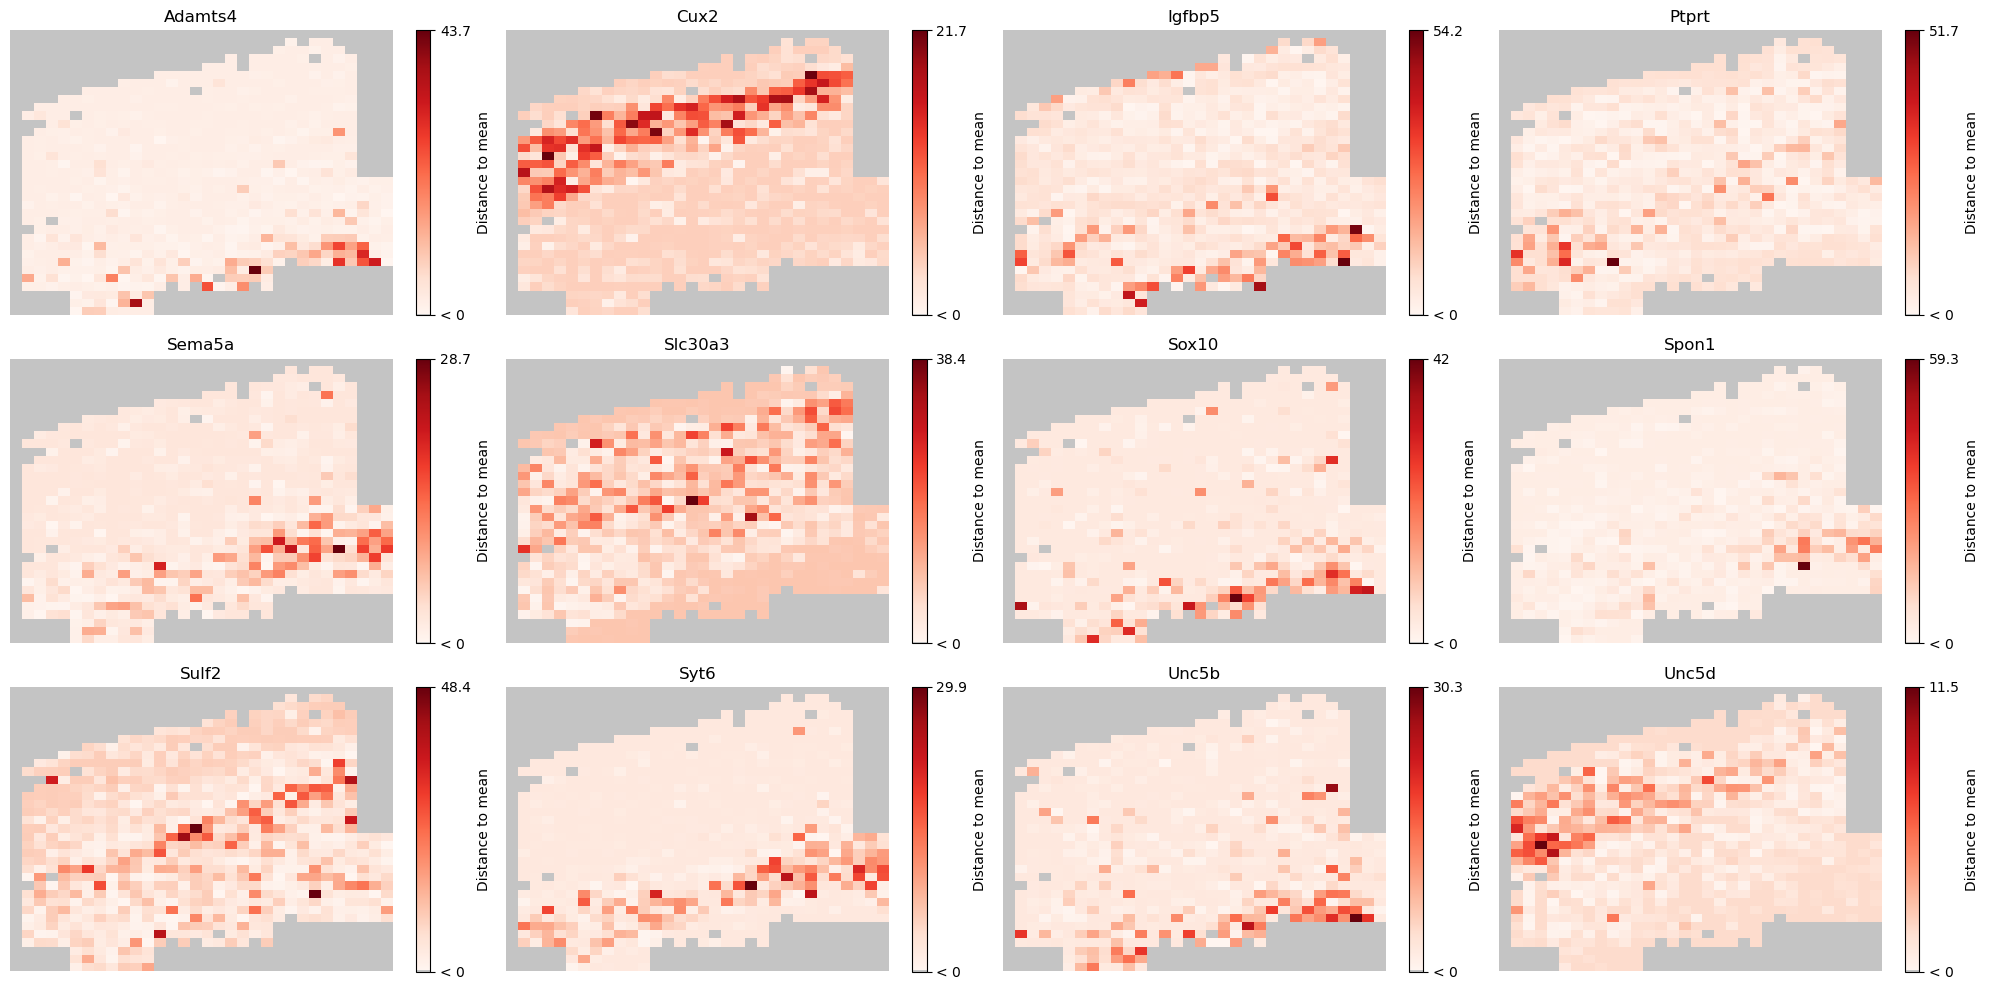

In [7]:
list_of_grids = []
for gene in top_genes:
    dist = spatial_gene_distance_grid(adata, gene, 60)
    list_of_grids.append(dist)

# Plot all grids in a single figure
fig, axes = plt.subplots(3, 4, figsize=(20, 10))
axes = axes.ravel()

for i, dist in enumerate(list_of_grids):

    dist.plot_distance(ax=axes[i], cmap="Reds")
    axes[i].set_title(f"{top_genes[i]}")
    axes[i].axis('off')
    print(f"{top_genes[i]} with variance {dist.variance}")

plt.tight_layout()
plt.show()

In [8]:
low_genes_dict = {'ttt': 10000}
maxmin_gene, maxmin_gene_var = 'ttt', 10000

for gene in gene_names:
    dist = spatial_gene_distance_grid(adata, gene, 1000)
    var = dist.variance
    if len(low_genes_dict) < 12:
        low_genes_dict[gene] = var
        if var > maxmin_gene_var:
            maxmin_gene, maxmin_gene_var = gene, var
    else:
        if var < maxmin_gene_var:
            low_genes_dict.pop(maxmin_gene)
            low_genes_dict[gene] = var
            # gets the new minmax gene from the top 10
            maxmin_gene = max(low_genes_dict, key=low_genes_dict.get)
            maxmin_gene_var = low_genes_dict[maxmin_gene]

top_genes = list(top_genes_dict.keys())

1700022I11Rik with variance 0.0050413959313782
5031425F14Rik with variance 0.005083508215652942
5730522E02Rik with variance 0.0062137412833063906
Ccdc162 with variance 0.0063799564942685644
Clrn1 with variance 0.00463866573342273
Dmkn with variance 0.014508428158479194
Fndc7 with variance 0.004335228606827443
Ltf with variance 0.005893453842808462
Mrgprx2 with variance 0.002503679167866758
Muc20 with variance 0.010886293817846246
Olah with variance 0.01723741148267296
Prok2 with variance 0.0030813680031054184


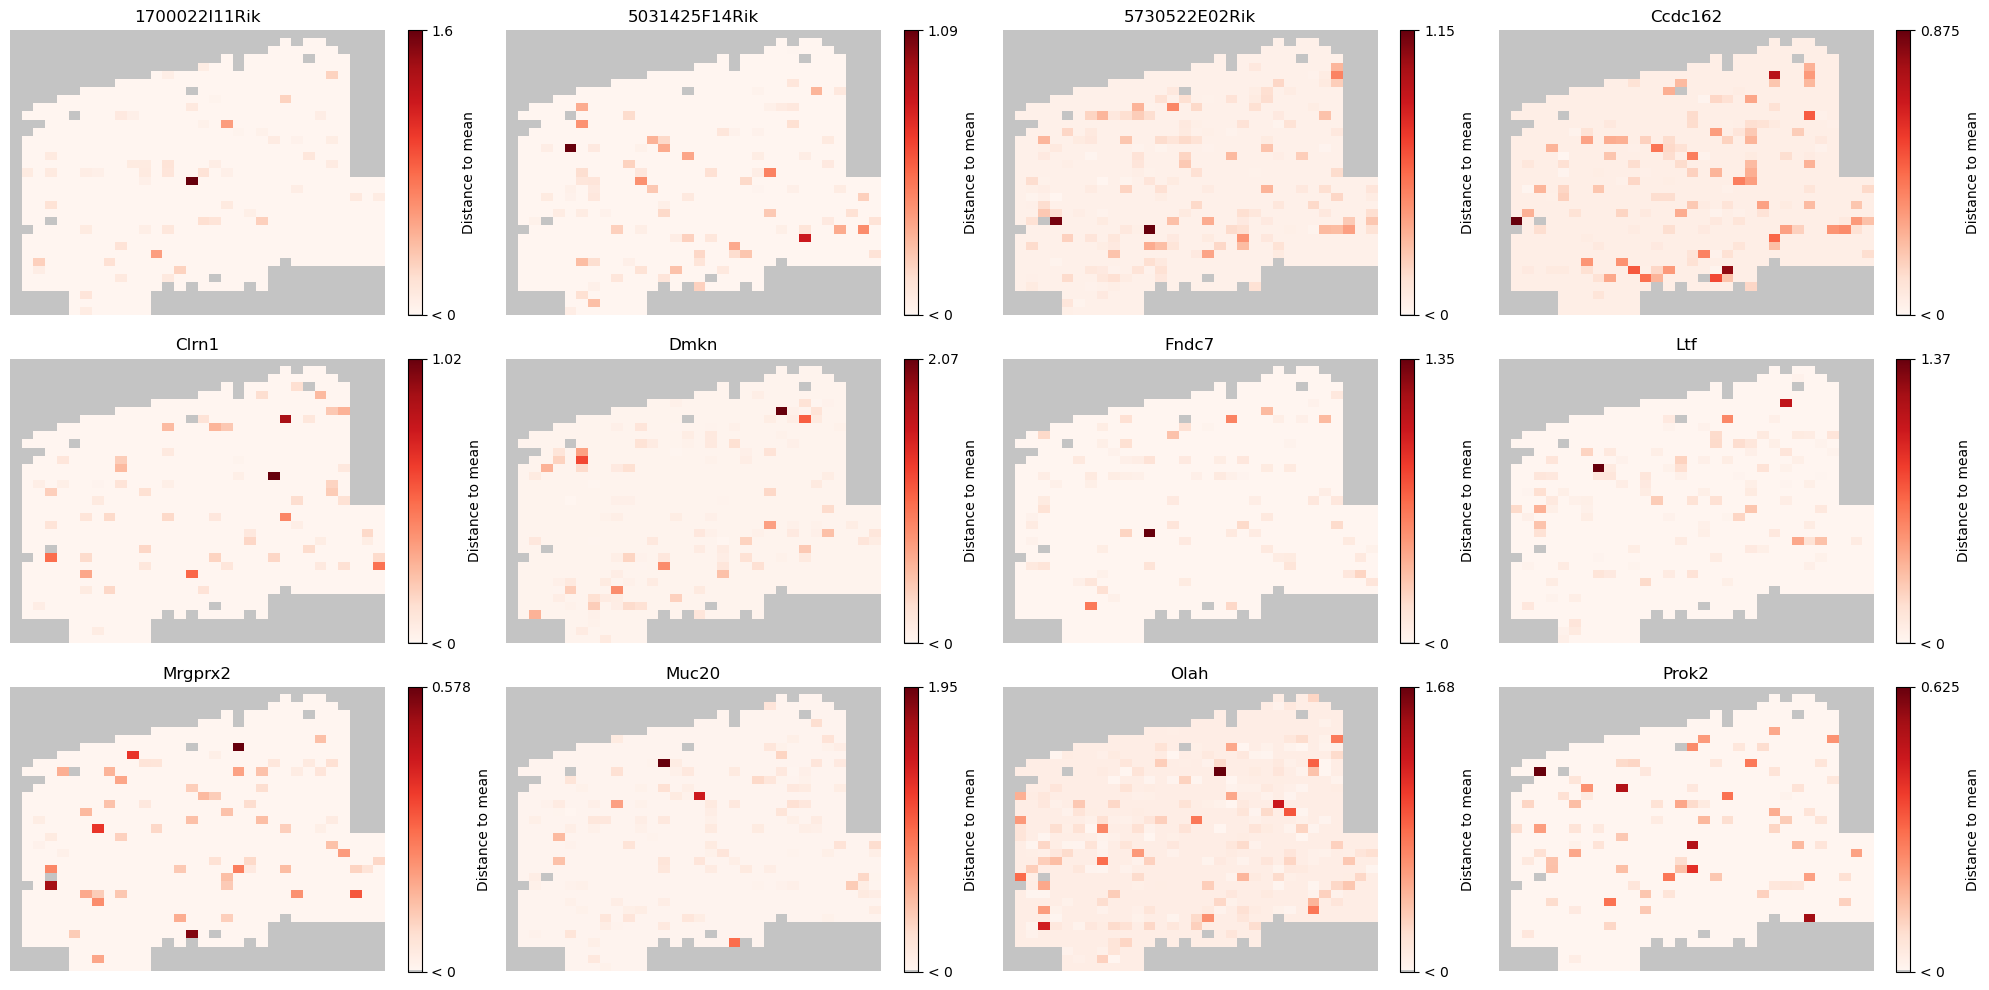

In [9]:
low_genes = list(low_genes_dict.keys())

list_of_grids = []
for gene in low_genes:
    dist = spatial_gene_distance_grid(adata, gene, 60)
    list_of_grids.append(dist)

# Plot all grids in a single figure
fig, axes = plt.subplots(3, 4, figsize=(20, 10))
axes = axes.ravel()

for i, dist in enumerate(list_of_grids):

    dist.plot_distance(ax=axes[i], cmap="Reds")
    axes[i].set_title(f"{low_genes[i]}")
    axes[i].axis('off')
    print(f"{low_genes[i]} with variance {dist.variance}")

plt.tight_layout()
plt.show()

## comparing test and ground truth samples

here we will take a sample with prediction and ground truth and try to measure the correctness of the preidction with different metrics

In [10]:
pred = '/home/asalmona/Documents/Ricci/code/LUNA_perturb/Spatial-Transcriptomics-and-Perturbations-Modeling/data_splits/mouse2_slice300_0/metadata_pred.csv'
ground_truth = '/home/asalmona/Documents/Ricci/code/LUNA_perturb/Spatial-Transcriptomics-and-Perturbations-Modeling/data_splits/mouse2_slice300_0/metadata_true.csv'

# load the samples
whole_pred_sample = pd.read_csv(pred)
whole_ground_truth_sample = pd.read_csv(ground_truth)

# get only the VLMC cells
pred_sample = whole_pred_sample[whole_pred_sample['cell_class'] == 'VLMC']
ground_truth_sample = whole_ground_truth_sample[whole_ground_truth_sample['cell_class'] == 'VLMC']


In [11]:
# plot points of a particular cell type in space using matplotlib

def plot_cell_type(df, cell_type_value, cell_type_col="cell_class", x_col="coord_X", y_col="coord_Y"):
    subset = df[df[cell_type_col] == cell_type_value]
    plt.figure(figsize=(6, 6))
    plt.scatter(subset[x_col], subset[y_col], s=30, alpha=0.7)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f'{cell_type_value} cells in spatial coordinates')
    plt.axis('equal')
    plt.show()

# Example usage:
# plot_cell_type(pred_sample, 'Astrocyte')

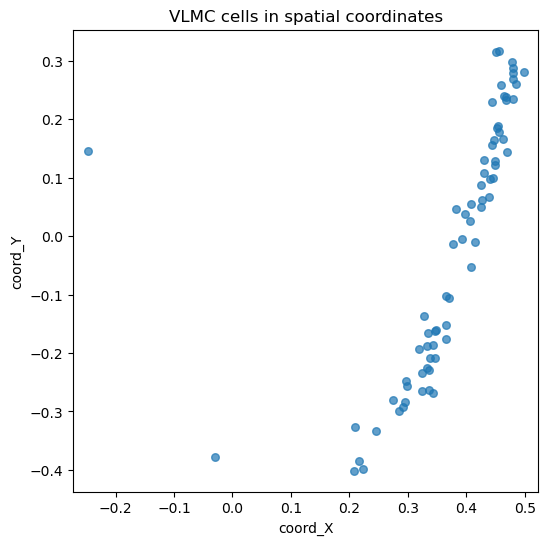

In [12]:
plot_cell_type(pred_sample, 'VLMC')

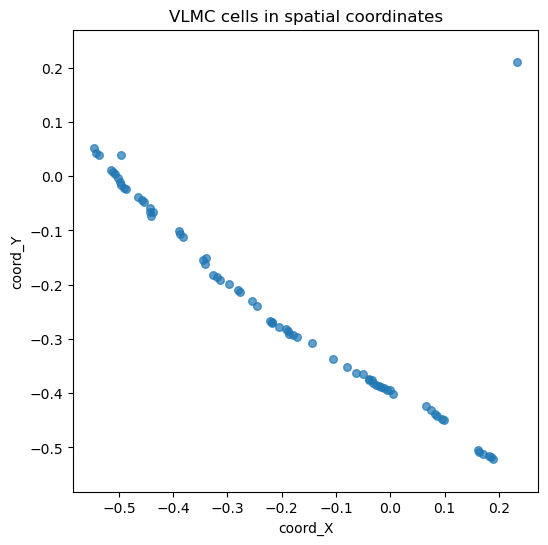

In [13]:
plot_cell_type(ground_truth_sample, 'VLMC')

In [14]:
from spectral_graph import align_prediction_rigid_to_ground_truth_by_id

# Align predicted coordinates to ground truth by cell ID
aligned_pred_sample = align_prediction_rigid_to_ground_truth_by_id(
    ground_truth_sample,
    pred_sample,
    cell_class_value='VLMC',
    id_col=0,
    coord_cols=('coord_X', 'coord_Y'),
    cell_class_col='cell_class',
    allow_reflection=False,
)


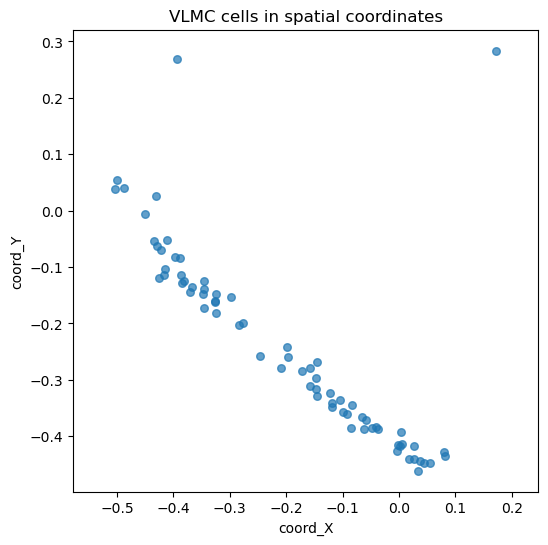

In [15]:
plot_cell_type(aligned_pred_sample, 'VLMC')

## from discrete to contiuous separeted phases

In [16]:
# compute the mean values of coordinates between the two point clouds
# we want a new point cloud that is the average of the two existing ones 

# get the coordinates of the two point clouds
coords_gt = ground_truth_sample[['coord_X', 'coord_Y']].values
coords_pred = aligned_pred_sample[['coord_X', 'coord_Y']].values

# compute the mean values of the coordinates
mean_coords = np.mean([coords_gt, coords_pred], axis=0)

# make a new dataframe with the mean coordinates
mean_coords_df = pd.DataFrame(mean_coords, columns=['coord_X', 'coord_Y'])
mean_coords_df['cell_class'] = 'VLMC'
mean_coords_df['cell_name'] = 'mean_coords'
mean_coords_df['sample_id'] = 'mean_coords'
mean_coords_df['cell_section'] = 'mean_coords'

# number of cells in the ground truth
print(len(ground_truth_sample))
n_cells = len(ground_truth_sample)

# create an artificial point cloud with cells evenly placed in a line
start_x = -0.5
end_x = 0.07
start_y = 0
end_y = -0.5

# create a new dataframe with the artificial point cloud
artificial_coords_x = np.linspace(start_x, end_x, n_cells-1)
artificial_coords_y = np.linspace(start_y, end_y, n_cells-1)  
# add small random noise to the coordinates
artificial_coords_x = artificial_coords_x + np.random.normal(0, 0.001, n_cells-1)
artificial_coords_y = artificial_coords_y + np.random.normal(0, 0.001, n_cells-1)
# add one point isolated in 0.2, 0.2
artificial_coords_x = np.append(artificial_coords_x, 0.2)
artificial_coords_y = np.append(artificial_coords_y, 0.2)
artificial_coords_df = pd.DataFrame(artificial_coords_x, columns=['coord_X'])
artificial_coords_df['coord_Y'] = artificial_coords_y
artificial_coords_df['cell_class'] = 'VLMC'
artificial_coords_df['cell_name'] = 'artificial_coords'
artificial_coords_df['sample_id'] = 'artificial_coords'
artificial_coords_df['cell_section'] = 'artificial_coords'

71


In [17]:
from cahn_hilliard import build_continuous_landscape_from_points, sigmoid_bump



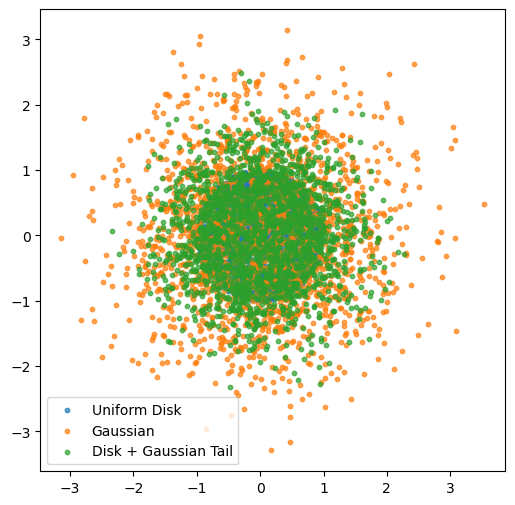

In [18]:
# build three point distributions

n = 2048

# Uniform random disk with hard boundary
r = np.sqrt(np.random.rand(n))  # radius: sqrt to ensure uniform density in the disk
theta = 2 * np.pi * np.random.rand(n)  # angle
disk_points = np.stack([r * np.cos(theta), r * np.sin(theta)], axis=1)

# Isotropic 2D Gaussian
gaussian_points = np.random.randn(n, 2)

# Disk with a gaussian tail: concatenate points inside disk and a tail of points outside disk
n_disk = int(0.6 * n)
n_tail = n - n_disk

# Disk points for main body
r_tail_disk = np.sqrt(np.random.rand(n_disk))
theta_tail_disk = 2 * np.pi * np.random.rand(n_disk)
disk_main = np.stack([r_tail_disk * np.cos(theta_tail_disk), r_tail_disk * np.sin(theta_tail_disk)], axis=1)

# Gaussian tail: points at larger radius, centered at the disk edge, with higher spread
tail_radius_center = 1  # start the tail just outside the disk
tail_r = tail_radius_center + 0.5 * np.abs(np.random.randn(n_tail))
tail_theta = 2 * np.pi * np.random.rand(n_tail)
tail_points = np.stack([tail_r * np.cos(tail_theta), tail_r * np.sin(tail_theta)], axis=1)

# Concatenate to form disk+tail
disk_gauss_tail_points = np.concatenate([disk_main, tail_points], axis=0)

# dataframes
# build the dataframes for the three point distributions
disk_points_df = pd.DataFrame(disk_points, columns=['coord_X', 'coord_Y'])
gaussian_points_df = pd.DataFrame(gaussian_points, columns=['coord_X', 'coord_Y'])
disk_gauss_tail_points_df = pd.DataFrame(disk_gauss_tail_points, columns=['coord_X', 'coord_Y'])

# bla bla bla
disk_points_df['cell_class'] = 'VLMC'
disk_points_df['cell_name'] = 'disk_points'
disk_points_df['sample_id'] = 'disk_points'
disk_points_df['cell_section'] = 'disk_points'

gaussian_points_df['cell_class'] = 'VLMC'
gaussian_points_df['cell_name'] = 'gaussian_points'
gaussian_points_df['sample_id'] = 'gaussian_points'
gaussian_points_df['cell_section'] = 'gaussian_points'

disk_gauss_tail_points_df['cell_class'] = 'VLMC'
disk_gauss_tail_points_df['cell_name'] = 'disk_gauss_tail_points'
disk_gauss_tail_points_df['sample_id'] = 'disk_gauss_tail_points'
disk_gauss_tail_points_df['cell_section'] = 'disk_gauss_tail_points'

# plot the three point distributions with smaller dots
plt.figure(figsize=(6, 6))
plt.scatter(disk_points[:, 0], disk_points[:, 1], s=10, alpha=0.7, label='Uniform Disk')
plt.scatter(gaussian_points[:, 0], gaussian_points[:, 1], s=10, alpha=0.7, label='Gaussian')
plt.scatter(disk_gauss_tail_points[:, 0], disk_gauss_tail_points[:, 1], s=10, alpha=0.7, label='Disk + Gaussian Tail')
plt.legend()
plt.show()

## continuous design

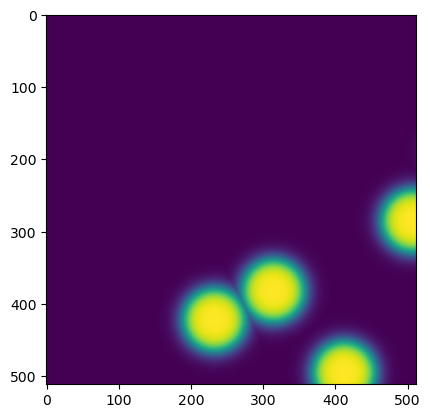

In [19]:
from cahn_hilliard import bump_gaussian


radius2 = 0.02
d = 128
shift = 4
landscape_gaussian = build_continuous_landscape_from_points(gaussian_points_df, bump_fn=sigmoid_bump, d=d, shift=shift, cell_class_col='cell_class', coord_cols=('coord_X', 'coord_Y'), cell_class_value='VLMC', radius=radius2, w_range=(-2.3, -1.7, -2.4, -1.8))
plt.imshow(landscape_gaussian.field)
plt.show()

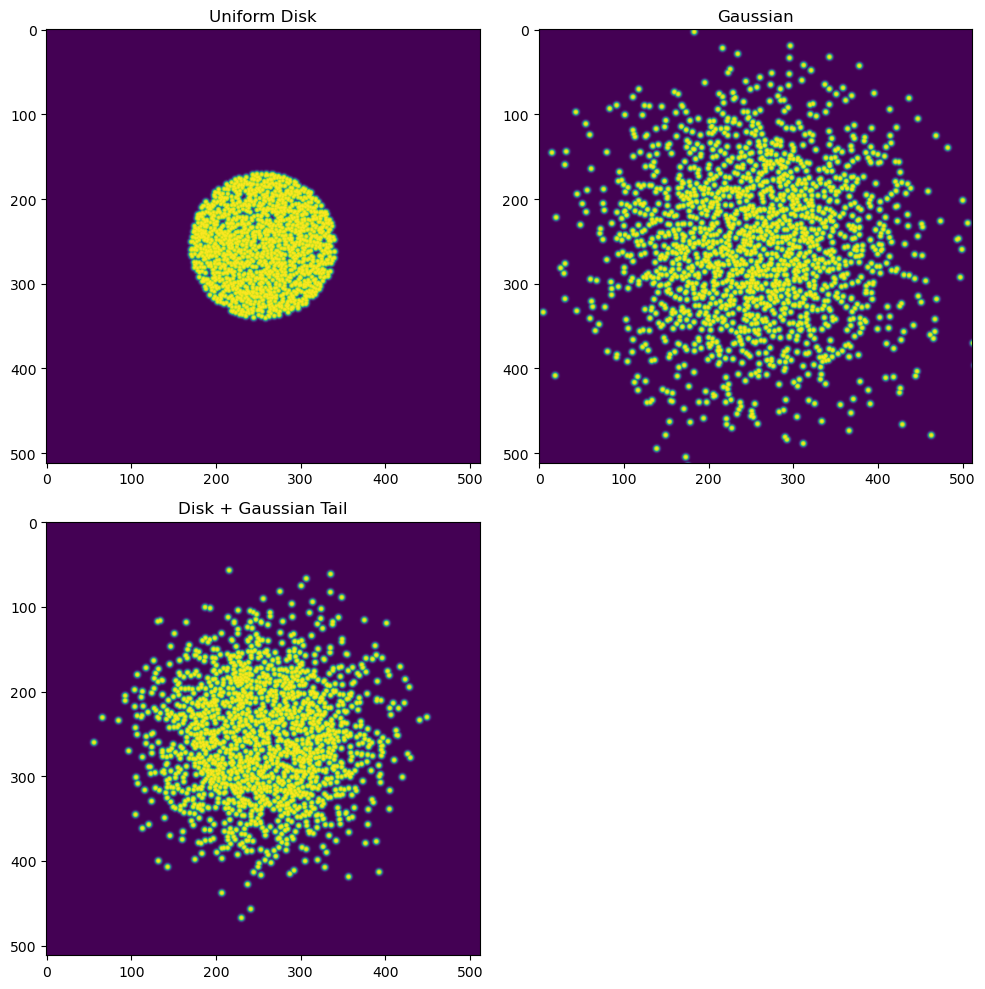

In [20]:
# plot smoothed landscapes
radius2 = 0.01
landscape_disk = build_continuous_landscape_from_points(disk_points_df, bump_fn=sigmoid_bump, d=d, shift=shift, cell_class_col='cell_class', coord_cols=('coord_X', 'coord_Y'), cell_class_value='VLMC', radius=radius2, w_range=(-3, 3, -3, 3))
landscape_gaussian = build_continuous_landscape_from_points(gaussian_points_df, bump_fn=sigmoid_bump, d=d, shift=shift, cell_class_col='cell_class', coord_cols=('coord_X', 'coord_Y'), cell_class_value='VLMC', radius=radius2, w_range=(-3, 3, -3, 3))
landscape_disk_gauss_tail = build_continuous_landscape_from_points(disk_gauss_tail_points_df, bump_fn=sigmoid_bump, d=d, shift=shift, cell_class_col='cell_class', coord_cols=('coord_X', 'coord_Y'), cell_class_value='VLMC', radius=radius2, w_range=(-3, 3, -3, 3))

# plot the three landscapes using correct subplot indices
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.imshow(landscape_disk.field)
plt.title('Uniform Disk')
plt.subplot(2, 2, 2)
plt.imshow(landscape_gaussian.field)
plt.title('Gaussian')
plt.subplot(2, 2, 3)
plt.imshow(landscape_disk_gauss_tail.field)
plt.title('Disk + Gaussian Tail')
plt.tight_layout()
plt.show()

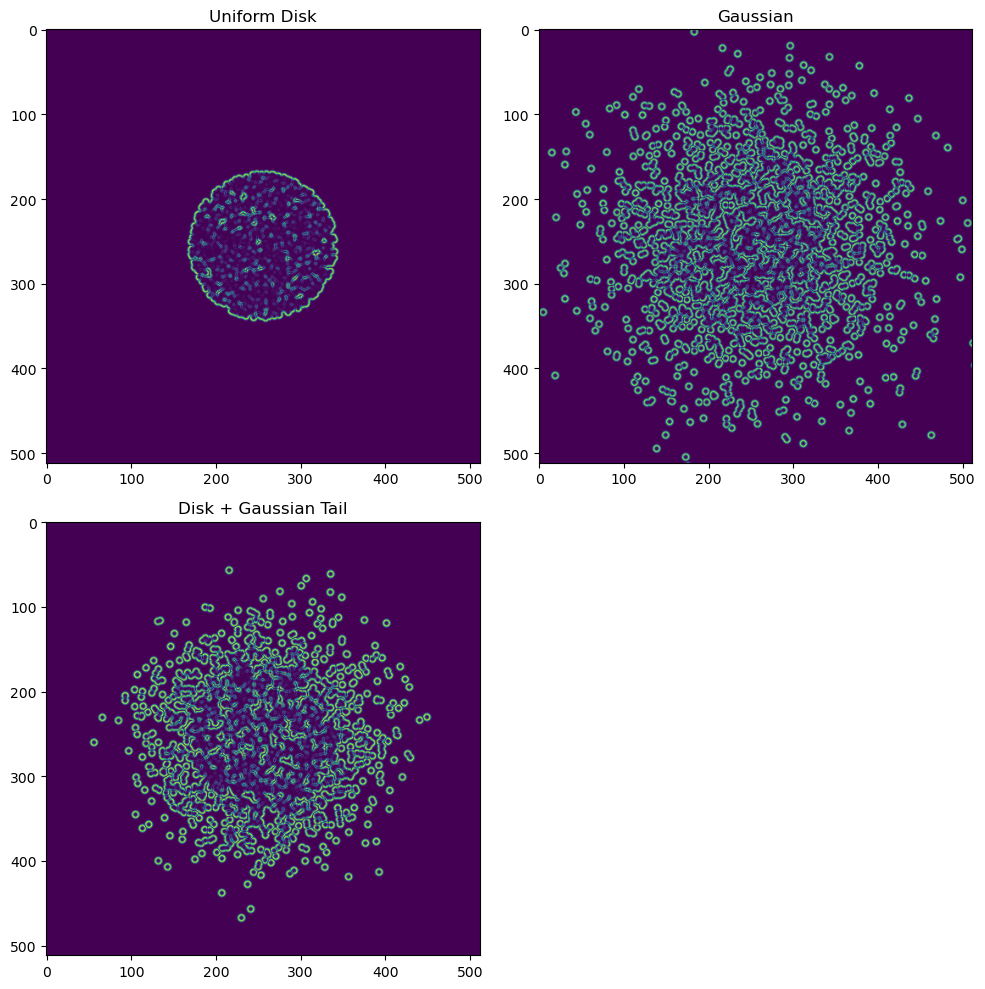

In [21]:
# compute the energy of the three landscapes
e_landscape_disk = landscape_disk.cahn_hilliard_energy_density(kappa=1)
e_landscape_gaussian = landscape_gaussian.cahn_hilliard_energy_density(kappa=1)
e_landscape_disk_gauss_tail = landscape_disk_gauss_tail.cahn_hilliard_energy_density(kappa=1)

# plot the energy of the three landscapes
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.imshow(e_landscape_disk)
plt.title('Uniform Disk')
plt.subplot(2, 2, 2)
plt.imshow(e_landscape_gaussian)
plt.title('Gaussian')
plt.subplot(2, 2, 3)
plt.imshow(e_landscape_disk_gauss_tail)
plt.title('Disk + Gaussian Tail')
plt.tight_layout()
plt.show()

In [22]:
# compute the energy of the three landscapes with different values of kappa
e_disk = landscape_disk.cahn_hilliard_energy(kappa=0.1)
e_gaussian = landscape_gaussian.cahn_hilliard_energy(kappa=0.1)
e_disk_gauss_tail = landscape_disk_gauss_tail.cahn_hilliard_energy(kappa=0.1)

print(f"Energy of Uniform Disk: {e_disk}")
print(f"Energy of Gaussian: {e_gaussian}")
print(f"Energy of Disk + Gaussian Tail: {e_disk_gauss_tail}")


Energy of Uniform Disk: 142.69093039800998
Energy of Gaussian: 1567.0196520931254
Energy of Disk + Gaussian Tail: 961.0733165819003


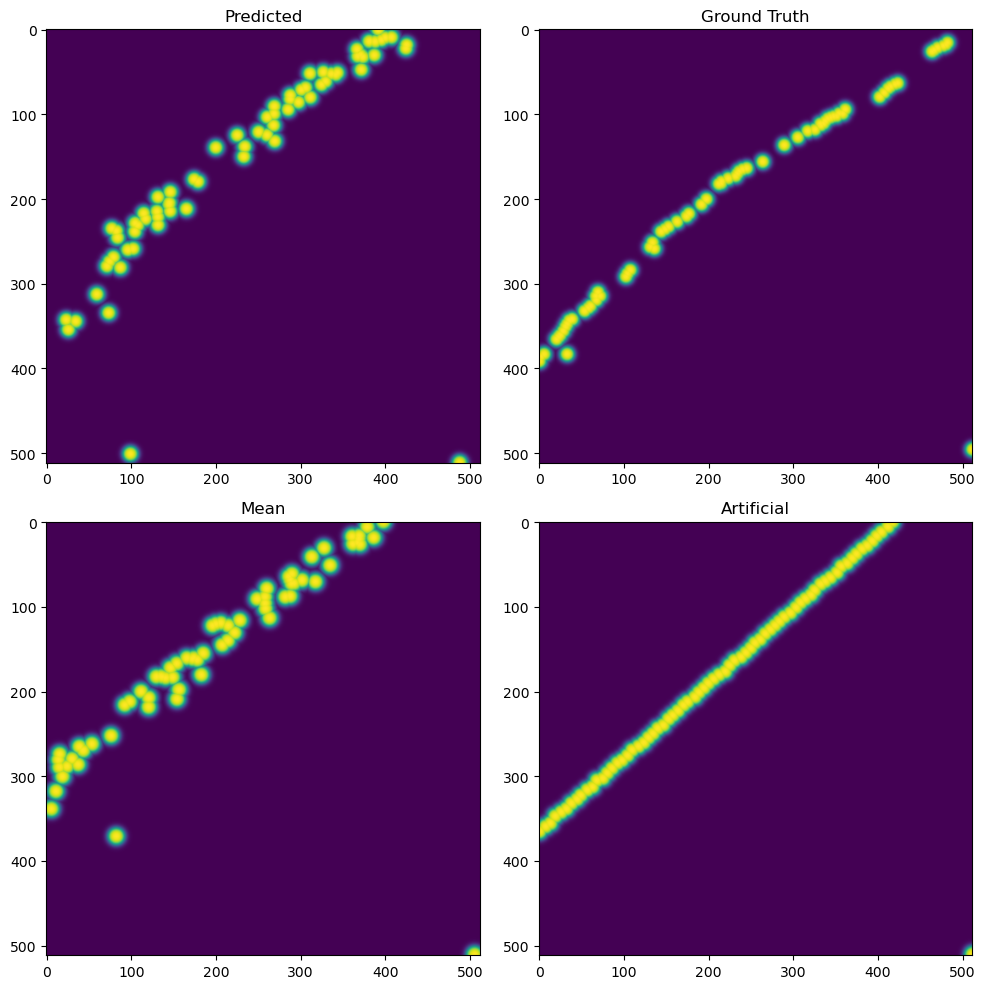

In [23]:
radius = 0.01
shift = 128*radius
d = 4/radius

# make a continuous landscape from the discrete point cloud
landscape_pred = build_continuous_landscape_from_points(aligned_pred_sample, bump_fn=sigmoid_bump, d=d, shift=shift, cell_class_col='cell_class', coord_cols=('coord_X', 'coord_Y'), cell_class_value='VLMC', radius=radius)
landscape_gt = build_continuous_landscape_from_points(ground_truth_sample, bump_fn=sigmoid_bump, d=d, shift=shift, cell_class_col='cell_class', coord_cols=('coord_X', 'coord_Y'), cell_class_value='VLMC', radius=radius)
landscape_mean = build_continuous_landscape_from_points(mean_coords_df, bump_fn=sigmoid_bump, d=d, shift=shift, cell_class_col='cell_class', coord_cols=('coord_X', 'coord_Y'), cell_class_value='VLMC', radius=radius)
landscape_artificial = build_continuous_landscape_from_points(artificial_coords_df, bump_fn=sigmoid_bump, d=d, shift=shift, cell_class_col='cell_class', coord_cols=('coord_X', 'coord_Y'), cell_class_value='VLMC', radius=radius)

# plot the four landscapes using correct subplot indices
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.imshow(landscape_pred.field)
plt.title('Predicted')
plt.subplot(2, 2, 2)
plt.imshow(landscape_gt.field)
plt.title('Ground Truth')
plt.subplot(2, 2, 3)
plt.imshow(landscape_mean.field)
plt.title('Mean')
plt.subplot(2, 2, 4)
plt.imshow(landscape_artificial.field)
plt.title('Artificial')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Artificial')

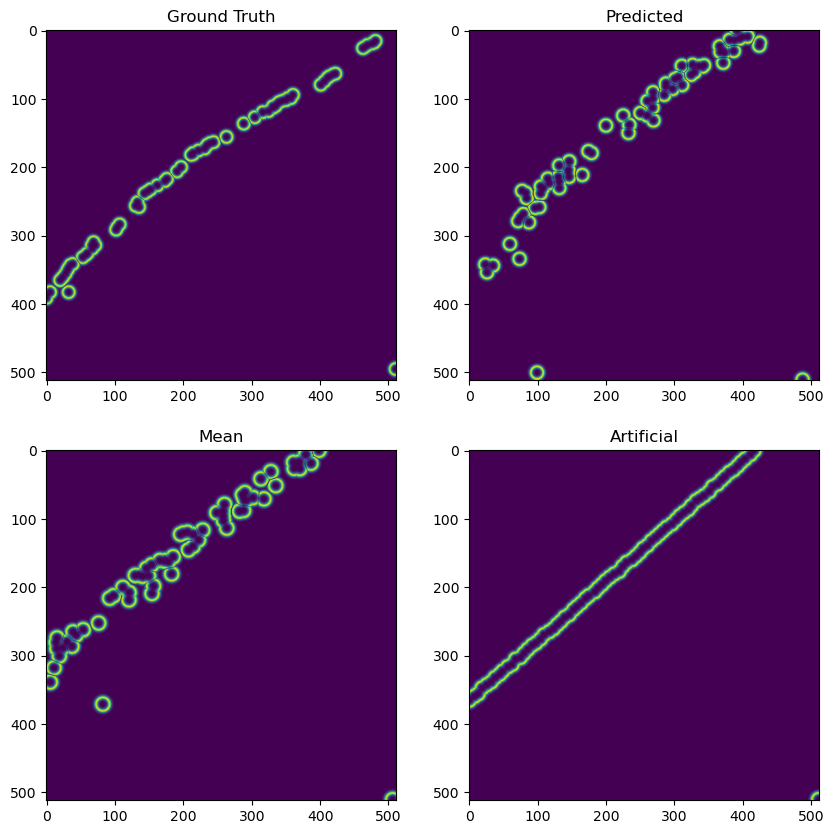

In [24]:
e_landscape_gt = landscape_gt.cahn_hilliard_energy_density(kappa=1)
e_landscape_pred = landscape_pred.cahn_hilliard_energy_density(kappa=1)
e_landscape_mean = landscape_mean.cahn_hilliard_energy_density(kappa=1)
e_landscape_artificial = landscape_artificial.cahn_hilliard_energy_density(kappa=1)

# plot the energy of the four landscapes
plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)
plt.imshow(e_landscape_gt)
plt.title('Ground Truth')
plt.subplot(2, 2, 2)
plt.imshow(e_landscape_pred)
plt.title('Predicted')
plt.subplot(2, 2, 3)
plt.imshow(e_landscape_mean)
plt.title('Mean')
plt.subplot(2, 2, 4)
plt.imshow(e_landscape_artificial)
plt.title('Artificial')


In [25]:
e_gt = landscape_gt.cahn_hilliard_energy(kappa=1)
e_pred = landscape_pred.cahn_hilliard_energy(kappa=1)
e_mean = landscape_mean.cahn_hilliard_energy(kappa=1)
e_artificial = landscape_artificial.cahn_hilliard_energy(kappa=1)

print(f"Energy of Ground Truth: {e_gt}")
print(f"Energy of Predicted: {e_pred}")
print(f"Energy of Mean: {e_mean}")
print(f"Energy of Artificial: {e_artificial}")

Energy of Ground Truth: 514.7575816079334
Energy of Predicted: 660.4699877185299
Energy of Mean: 600.6843189168917
Energy of Artificial: 417.0706294808322


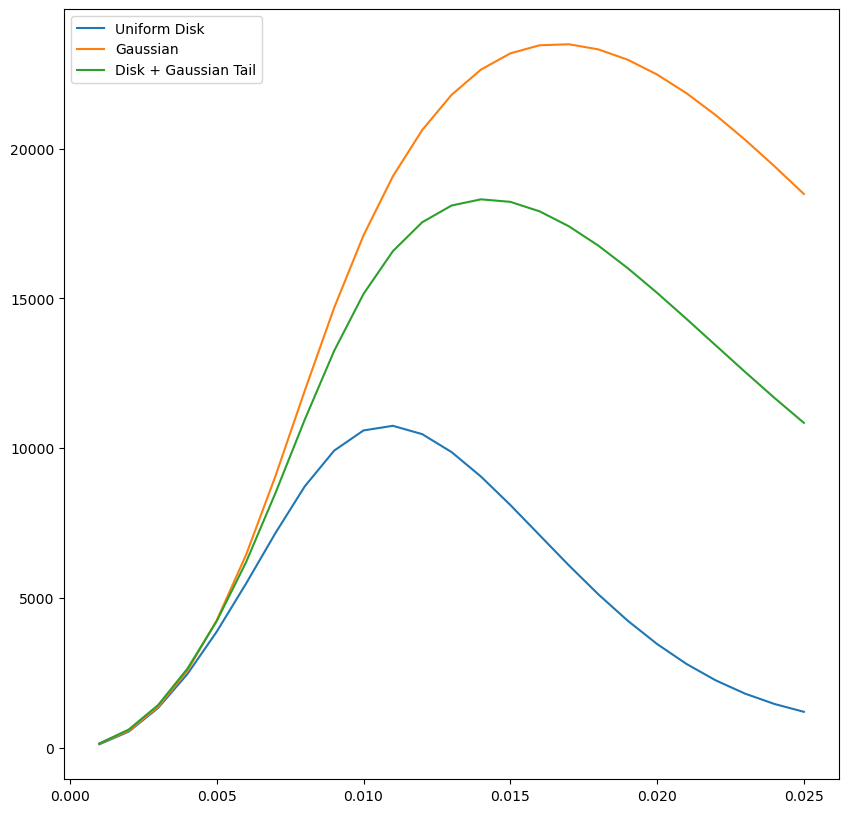

In [26]:
radii = np.linspace(0.001, 0.025, 25)

energies_disk = []
energies_gaussian = []
energies_disk_gauss_tail = []

for radius in radii:
    d = 4/radius
    shift = 128*radius
    r_landscape_disk = build_continuous_landscape_from_points(disk_points_df, bump_fn=sigmoid_bump, d=d, shift=shift, cell_class_col='cell_class', coord_cols=('coord_X', 'coord_Y'), cell_class_value='VLMC', radius=radius, w_range=(-3, 3, -3, 3))
    r_landscape_gaussian = build_continuous_landscape_from_points(gaussian_points_df, bump_fn=sigmoid_bump, d=d, shift=shift, cell_class_col='cell_class', coord_cols=('coord_X', 'coord_Y'), cell_class_value='VLMC', radius=radius, w_range=(-3, 3, -3, 3))
    r_landscape_disk_gauss_tail = build_continuous_landscape_from_points(disk_gauss_tail_points_df, bump_fn=sigmoid_bump, d=d, shift=shift, cell_class_col='cell_class', coord_cols=('coord_X', 'coord_Y'), cell_class_value='VLMC', radius=radius, w_range=(-3, 3, -3, 3))
    e_disk = r_landscape_disk.cahn_hilliard_energy(kappa=1)
    e_gaussian = r_landscape_gaussian.cahn_hilliard_energy(kappa=1)
    e_disk_gauss_tail = r_landscape_disk_gauss_tail.cahn_hilliard_energy(kappa=1)
    energies_disk.append(e_disk)
    energies_gaussian.append(e_gaussian)
    energies_disk_gauss_tail.append(e_disk_gauss_tail)

# plot the energies of the three landscapes as a function of the radius
plt.figure(figsize=(10, 10))
plt.plot(radii, energies_disk, label='Uniform Disk')
plt.plot(radii, energies_gaussian, label='Gaussian')
plt.plot(radii, energies_disk_gauss_tail, label='Disk + Gaussian Tail')
plt.legend()
plt.show()

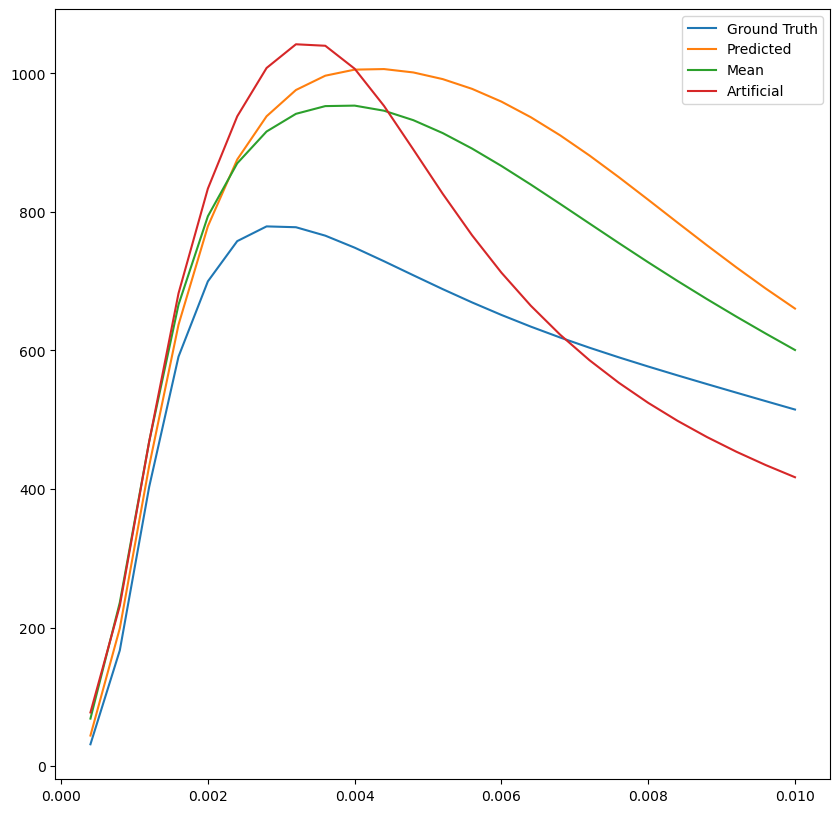

In [27]:
# same with the real pred and gt etc
radii = np.linspace(0.0004, 0.01, 25)

energies_gt = []
energies_pred = []
energies_mean = []
energies_artificial = []

for radius in radii:
    d = 4/radius
    shift = 128*radius
    r_landscape_gt = build_continuous_landscape_from_points(ground_truth_sample, bump_fn=sigmoid_bump, d=d, shift=shift, cell_class_col='cell_class', coord_cols=('coord_X', 'coord_Y'), cell_class_value='VLMC', radius=radius)
    r_landscape_pred = build_continuous_landscape_from_points(aligned_pred_sample, bump_fn=sigmoid_bump, d=d, shift=shift, cell_class_col='cell_class', coord_cols=('coord_X', 'coord_Y'), cell_class_value='VLMC', radius=radius)
    r_landscape_mean = build_continuous_landscape_from_points(mean_coords_df, bump_fn=sigmoid_bump, d=d, shift=shift, cell_class_col='cell_class', coord_cols=('coord_X', 'coord_Y'), cell_class_value='VLMC', radius=radius)
    r_landscape_artificial = build_continuous_landscape_from_points(artificial_coords_df, bump_fn=sigmoid_bump, d=d, shift=shift, cell_class_col='cell_class', coord_cols=('coord_X', 'coord_Y'), cell_class_value='VLMC', radius=radius )
    e_gt = r_landscape_gt.cahn_hilliard_energy(kappa=1)
    e_pred = r_landscape_pred.cahn_hilliard_energy(kappa=1)
    e_mean = r_landscape_mean.cahn_hilliard_energy(kappa=1)
    e_artificial = r_landscape_artificial.cahn_hilliard_energy(kappa=1)
    energies_gt.append(e_gt)
    energies_pred.append(e_pred)
    energies_mean.append(e_mean)
    energies_artificial.append(e_artificial)

# plot the energies of the four landscapes as a function of the radius
plt.figure(figsize=(10, 10))
plt.plot(radii, energies_gt, label='Ground Truth')
plt.plot(radii, energies_pred, label='Predicted')
plt.plot(radii, energies_mean, label='Mean')
plt.plot(radii, energies_artificial, label='Artificial')
plt.legend()
plt.show()

In [28]:
from cahn_hilliard import common_match_key


def plot_ch_energy_curves(type, radius):
    # Compute for radius of 0.005
    radius = radius
    d = 4 / radius
    shift = 128 * radius

    # Compute landscape fields for SMC (ground truth and predicted)
    smc_gt_landscape = build_continuous_landscape_from_points(
        whole_ground_truth_sample,
        bump_fn=sigmoid_bump, d=d, shift=shift,
        cell_class_col='cell_class', coord_cols=('coord_X', 'coord_Y'),
        cell_class_value=type, radius=radius
    )
    smc_pred_landscape = build_continuous_landscape_from_points(
        whole_pred_sample,
        bump_fn=sigmoid_bump, d=d, shift=shift,
        cell_class_col='cell_class', coord_cols=('coord_X', 'coord_Y'),
        cell_class_value=type, radius=radius
    )
    common_key = common_match_key(smc_gt_landscape.global_key(), smc_pred_landscape.global_key())

    # Compute energy fields
    e_landscape_gt_smc = smc_gt_landscape.cahn_hilliard_energy_density(kappa=1)
    e_landscape_pred_smc = smc_pred_landscape.cahn_hilliard_energy_density(kappa=1)

    # Compute energy curves as function of radius
    energies_gt_smc = []
    energies_pred_smc = []

    for r in radii:
        r_landscape_gt_smc = build_continuous_landscape_from_points(
            whole_ground_truth_sample, cell_class_col='cell_class',
            coord_cols=('coord_X', 'coord_Y'), cell_class_value=type, radius=r, match_key=common_key
        )
        r_landscape_pred_smc = build_continuous_landscape_from_points(
            whole_pred_sample, cell_class_col='cell_class',
            coord_cols=('coord_X', 'coord_Y'), cell_class_value=type, radius=r, match_key=common_key
        )
        e_gt_smc = r_landscape_gt_smc.cahn_hilliard_energy(kappa=1)
        e_pred_smc = r_landscape_pred_smc.cahn_hilliard_energy(kappa=1)
        energies_gt_smc.append(e_gt_smc)
        energies_pred_smc.append(e_pred_smc)

    fig = plt.figure(figsize=(18, 12))
    gs = gridspec.GridSpec(2, 3, height_ratios=[1.2, 0.8])

    # Row 0: landscapes and energy densities
    ax00 = fig.add_subplot(gs[0, 0])
    im0 = ax00.imshow(smc_gt_landscape.field)
    ax00.set_title(f'{type} Landscape\nGround Truth')
    plt.colorbar(im0, ax=ax00, fraction=0.046, pad=0.04)

    ax01 = fig.add_subplot(gs[0, 1])
    im1 = ax01.imshow(smc_pred_landscape.field)
    ax01.set_title(f'{type} Landscape\nPredicted')
    plt.colorbar(im1, ax=ax01, fraction=0.046, pad=0.04)

    ax02 = fig.add_subplot(gs[0, 2])
    im2 = ax02.imshow(e_landscape_gt_smc)
    ax02.set_title('CH Energy Density\nGround Truth')
    plt.colorbar(im2, ax=ax02, fraction=0.046, pad=0.04)

    # Row 1: predicted energy density and energy curves (ax12 left empty for symmetry)
    ax10 = fig.add_subplot(gs[1, 0])
    im3 = ax10.imshow(e_landscape_pred_smc)
    ax10.set_title('CH Energy Density\nPredicted')
    plt.colorbar(im3, ax=ax10, fraction=0.046, pad=0.04)

    ax11 = fig.add_subplot(gs[1, 1:])
    ax11.plot(radii, energies_gt_smc, label='Ground Truth')
    ax11.plot(radii, energies_pred_smc, label='Predicted')
    ax11.set_xlabel("Radius")
    ax11.set_ylabel("Total Cahn-Hilliard Energy")
    ax11.set_title(f"Energy vs Radius ({type})")
    ax11.legend()

    plt.tight_layout()
    plt.show()

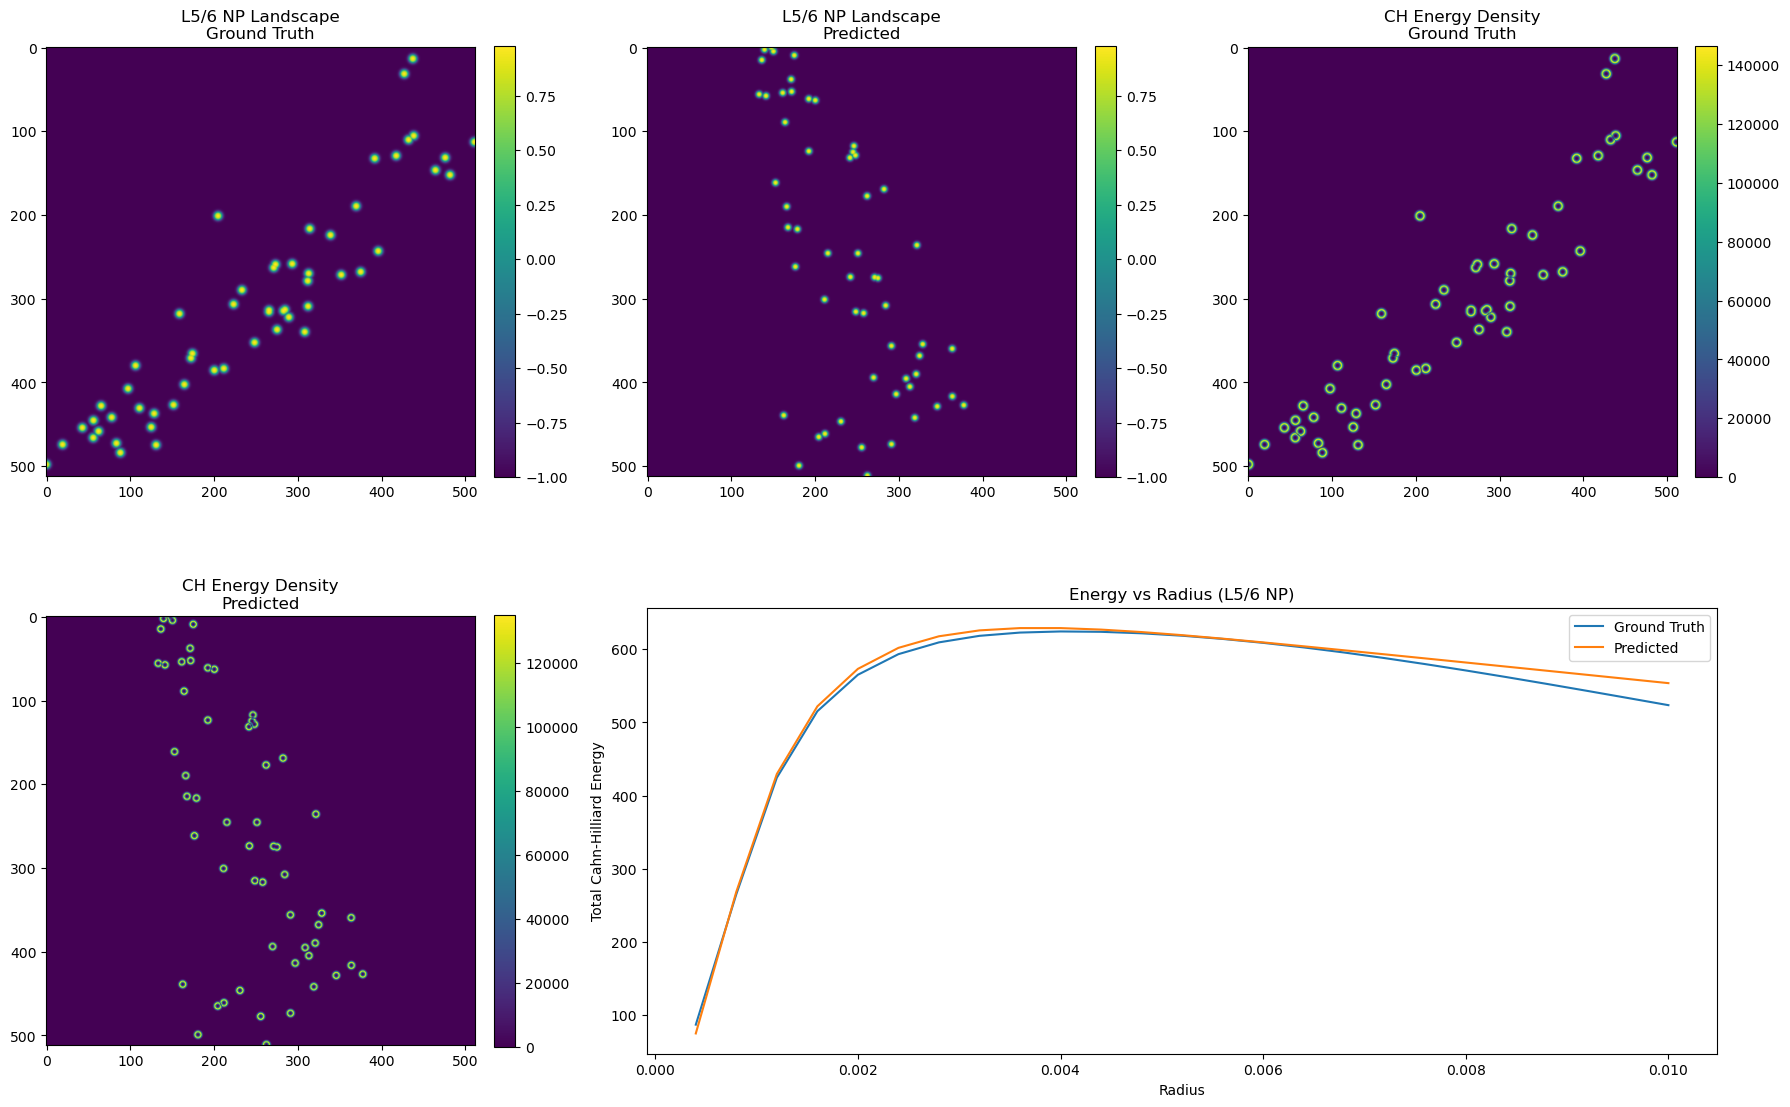

In [29]:
plot_ch_energy_curves('L5/6 NP', 0.005)

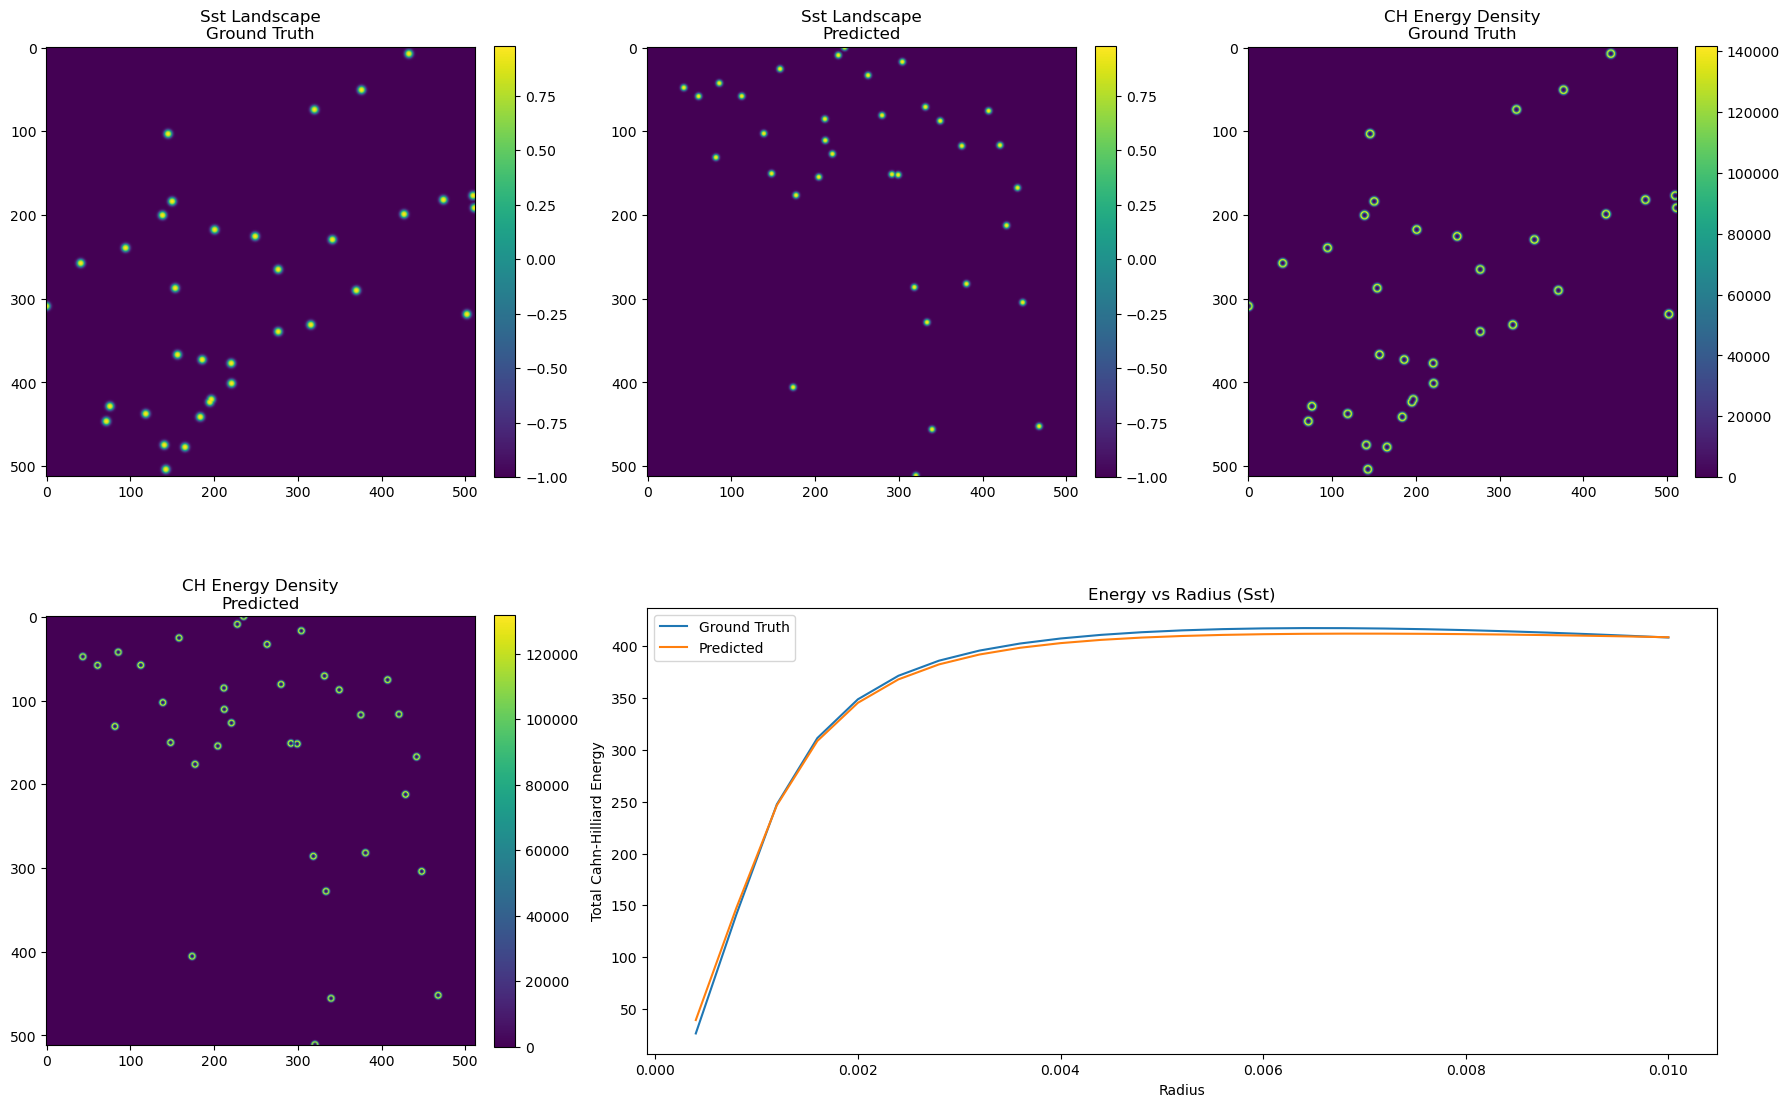

In [30]:
plot_ch_energy_curves('Sst', 0.005)

# Comparing phase separation between 2 cell types 

## first steps

In [55]:
from cahn_hilliard import build_voronoi_phase_landscape_from_cell_types


In [128]:
# plot points for two cell types, in different colors, in one plot using matplotlib

def plot_two_cell_types(df, cell_type_value1, cell_type_value2, cell_type_col="cell_class", x_col="coord_X", y_col="coord_Y", colors=("tab:blue", "tab:orange"), landscape=None, energy=False):
    subset1 = df[df[cell_type_col] == cell_type_value1]
    subset2 = df[df[cell_type_col] == cell_type_value2]
    if landscape is None:
        plt.figure(figsize=(6, 6))
        plt.scatter(-subset1[y_col], subset1[x_col], s=30, alpha=0.7, label=f"{cell_type_value1}", color=colors[0])
        plt.scatter(-subset2[y_col], subset2[x_col], s=30, alpha=0.7, label=f"{cell_type_value2}", color=colors[1])
        plt.xlabel(y_col)
        plt.ylabel(x_col)
        plt.title(f'{cell_type_value1} and {cell_type_value2} cells in spatial coordinates')
        plt.axis('equal')
        plt.legend()
        plt.show()
    else:  # makes a plot with cells and landscape, or three plots if energy
        if energy:
            e = landscape.cahn_hilliard_energy(kappa=1)
            plt.figure(figsize=(18, 6))
            # 1. Energy Density
            e_landscape = landscape.cahn_hilliard_energy_density(kappa=1)
            plt.subplot(1, 3, 1)
            plt.imshow(e_landscape)
            plt.title("Energy Density")
            # 2. Landscape
            plt.subplot(1, 3, 2)
            plt.imshow(landscape.field)
            plt.title("Landscape")
            # 3. Cells
            plt.subplot(1, 3, 3)
            plt.scatter(subset1[y_col], -subset1[x_col], s=30, alpha=0.7, label=f"{cell_type_value1}", color=colors[0])
            plt.scatter(subset2[y_col], -subset2[x_col], s=30, alpha=0.7, label=f"{cell_type_value2}", color=colors[1])
            plt.xlabel(y_col)
            plt.ylabel(x_col)
            plt.title(f'{cell_type_value1} and {cell_type_value2} cells in spatial coordinates')
            plt.axis('equal')
            plt.legend()
            # Add the value e on the bottom of the plot
            plt.gcf().text(0.5, 0.02, f'Total Cahn-Hilliard energy: {e:.4f}', ha='center', va='center', fontsize=14)
            plt.tight_layout(rect=(0, 0.04, 1, 1))
            plt.show()
        else:
            plt.figure(figsize=(12, 6))
            # 1. Landscape
            plt.subplot(1, 2, 1)
            plt.imshow(landscape.field)
            plt.title("Landscape")
            # 2. Cells
            plt.subplot(1, 2, 2)
            plt.scatter(subset1[y_col], -subset1[x_col], s=30, alpha=0.7, label=f"{cell_type_value1}", color=colors[0])
            plt.scatter(subset2[y_col], -subset2[x_col], s=30, alpha=0.7, label=f"{cell_type_value2}", color=colors[1])
            plt.xlabel(y_col)
            plt.ylabel(x_col)
            plt.title(f'{cell_type_value1} and {cell_type_value2} cells in spatial coordinates')
            plt.axis('equal')
            plt.legend()
            plt.tight_layout()
            plt.show()

# Example usage:
# plot_two_cell_types(pred_sample, 'Astrocyte', 'VLMC')

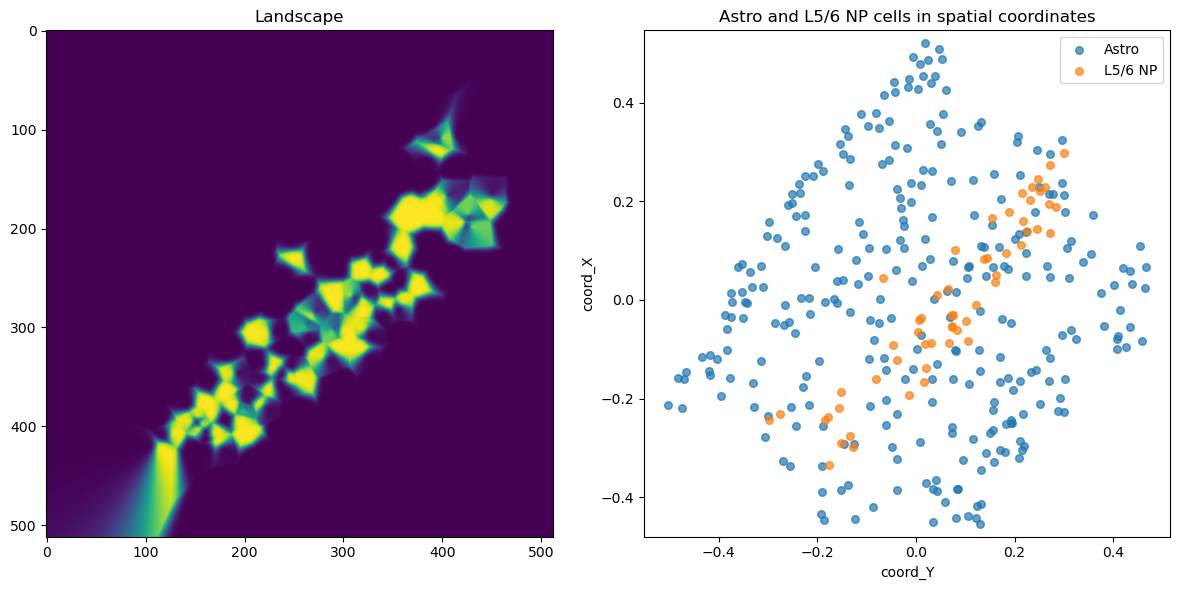

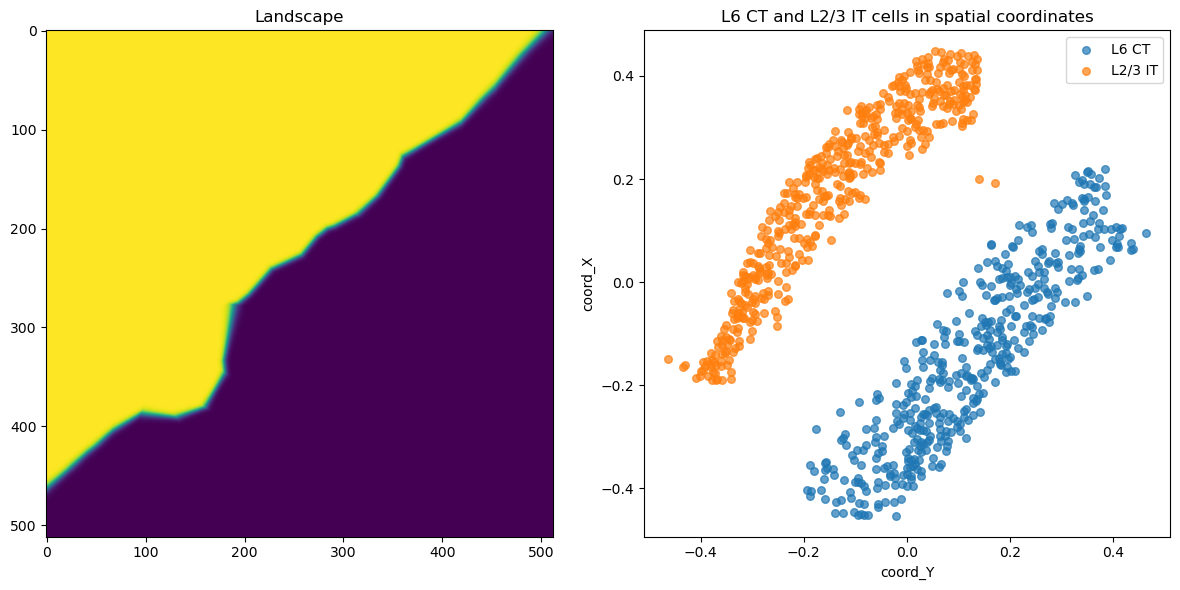

In [108]:
# landscape
cell_1 = 'Astro'
cell_2 = 'L5/6 NP'
# let's try
landscape_2_types_scat = build_voronoi_phase_landscape_from_cell_types(df=whole_ground_truth_sample, negative_cell_class_value=cell_1, positive_cell_class_value=cell_2, transition_width=0.01)

# plot 
plot_two_cell_types(whole_ground_truth_sample, cell_1, cell_2, landscape=landscape_2_types_scat)

# landscape
cell_3 = 'L6 CT'
cell_4 = 'L2/3 IT'
# let's try
landscape_2_types = build_voronoi_phase_landscape_from_cell_types(df=whole_ground_truth_sample, negative_cell_class_value=cell_3, positive_cell_class_value=cell_4, transition_width=0.01)

# plot 
plot_two_cell_types(whole_ground_truth_sample, cell_3, cell_4, landscape=landscape_2_types)

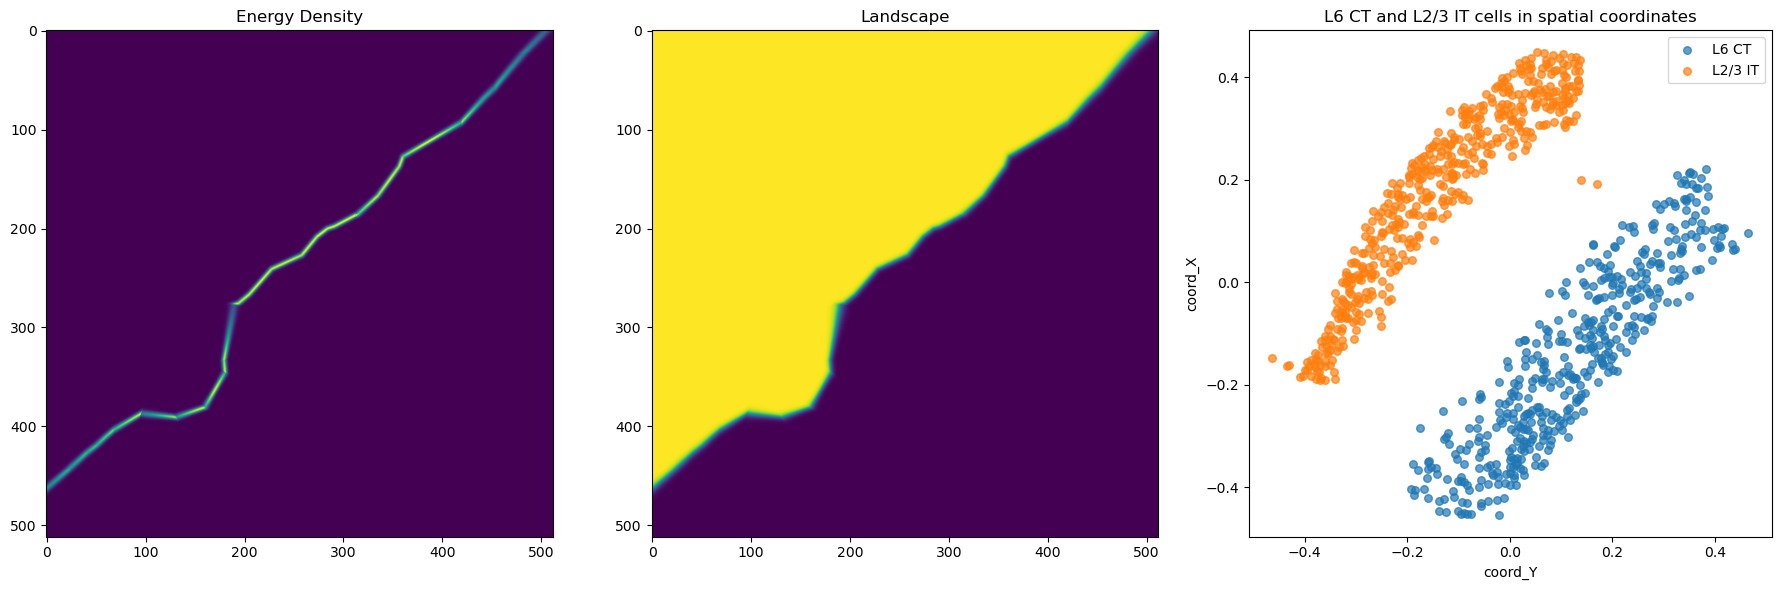

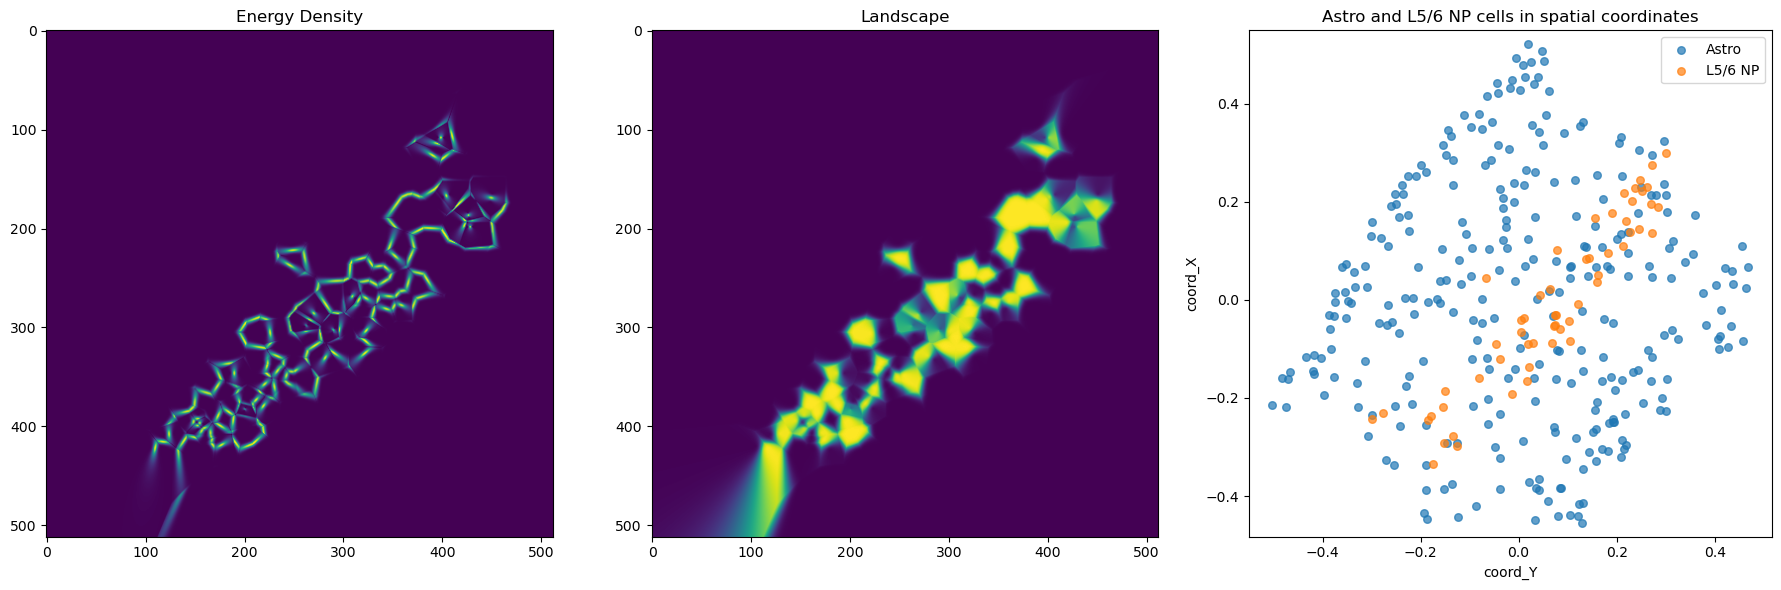

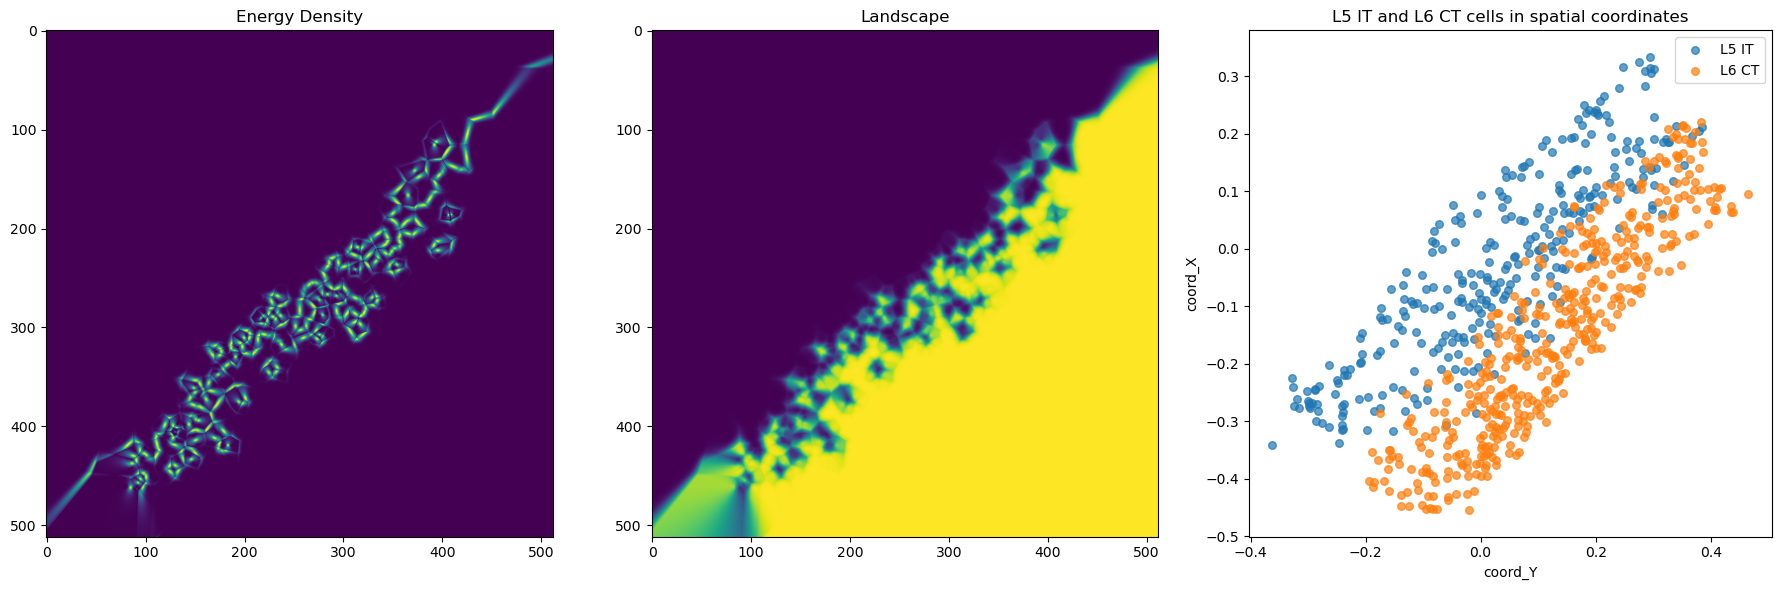

Energy of landscape_2_types: 299.9794696300211
Energy of landscape_2_types_scat: 871.200620511143
Energy of landscape_3: 775.9813168332456


In [114]:
# compute energies
# plot 
plot_two_cell_types(whole_ground_truth_sample, cell_3, cell_4, landscape=landscape_2_types, energy=True)
plot_two_cell_types(whole_ground_truth_sample, cell_1, cell_2, landscape=landscape_2_types_scat, energy=True)

cell_5 = "L5 IT"
landscape_3 = build_voronoi_phase_landscape_from_cell_types(df=whole_ground_truth_sample, negative_cell_class_value=cell_5, positive_cell_class_value=cell_3, transition_width=0.01)
plot_two_cell_types(whole_ground_truth_sample, cell_5, cell_3, landscape=landscape_3, energy=True)

# energy values
e_landscape_2_types = landscape_2_types.cahn_hilliard_energy(kappa=1)
e_landscape_2_types_scat = landscape_2_types_scat.cahn_hilliard_energy(kappa=1)
e_landscape_3 = landscape_3.cahn_hilliard_energy(kappa=1)

print(f"Energy of landscape_2_types: {e_landscape_2_types}")
print(f"Energy of landscape_2_types_scat: {e_landscape_2_types_scat}")
print(f"Energy of landscape_3: {e_landscape_3}")

In [140]:
# for each pair of cell type, compute the cahn-hilliard energy density and rank these pairs on the highest energy levels
pair_energies = {}
i = 0
already = []
for cell_type_value1 in whole_ground_truth_sample["cell_class"].unique():
    already.append(cell_type_value1)
    for cell_type_value2 in whole_ground_truth_sample["cell_class"].unique():
        if cell_type_value1 != cell_type_value2 and cell_type_value2 not in already:
            landscape = build_voronoi_phase_landscape_from_cell_types(df=whole_ground_truth_sample, negative_cell_class_value=cell_type_value1, positive_cell_class_value=cell_type_value2, transition_width=0.01)
            e_landscape = landscape.cahn_hilliard_energy(kappa=1)
            pair_energies[f"{cell_type_value1} - {cell_type_value2}"] = e_landscape
            i += 1

print(f"Compared {i} pairs")



Compared 231 pairs


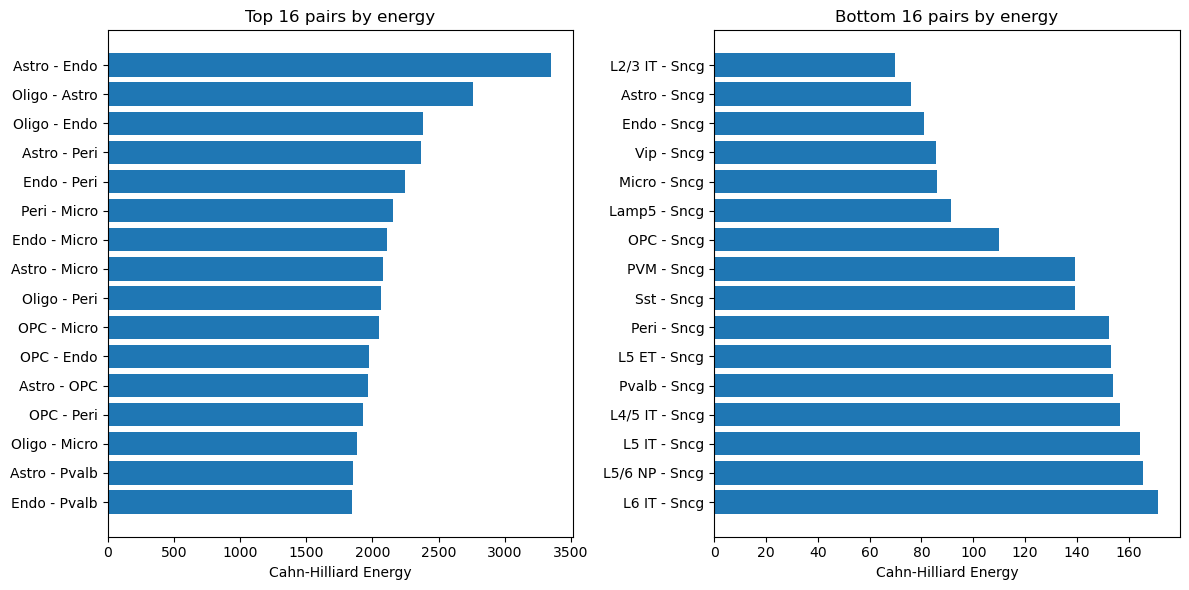

In [141]:
# sort the pairs by energy
sorted_pair_energies = sorted(pair_energies.items(), key=lambda x: x[1], reverse=True)

# Unpack the sorted pairs into labels (pair names) and their energies
pair_labels, energies = zip(*sorted_pair_energies)

# Plot top ten pairs
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.barh(pair_labels[:16][::-1], energies[:16][::-1])  # Reverse for most to least at top
plt.title("Top 16 pairs by energy")
plt.xlabel("Cahn-Hilliard Energy")
plt.tight_layout()

# Plot bottom ten pairs
plt.subplot(1, 2, 2)
plt.barh(pair_labels[-16:], energies[-16:])
plt.title("Bottom 16 pairs by energy")
plt.xlabel("Cahn-Hilliard Energy")
plt.tight_layout()
plt.show()

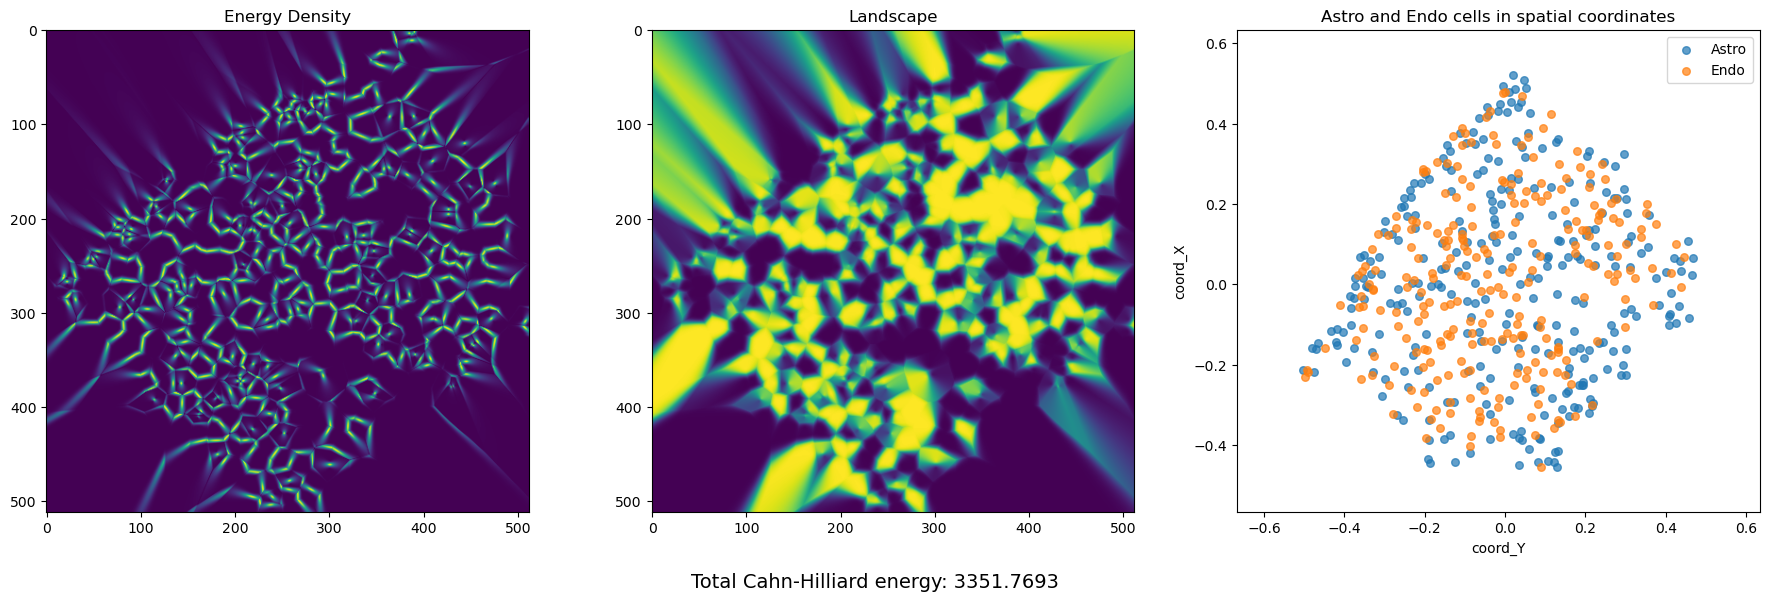

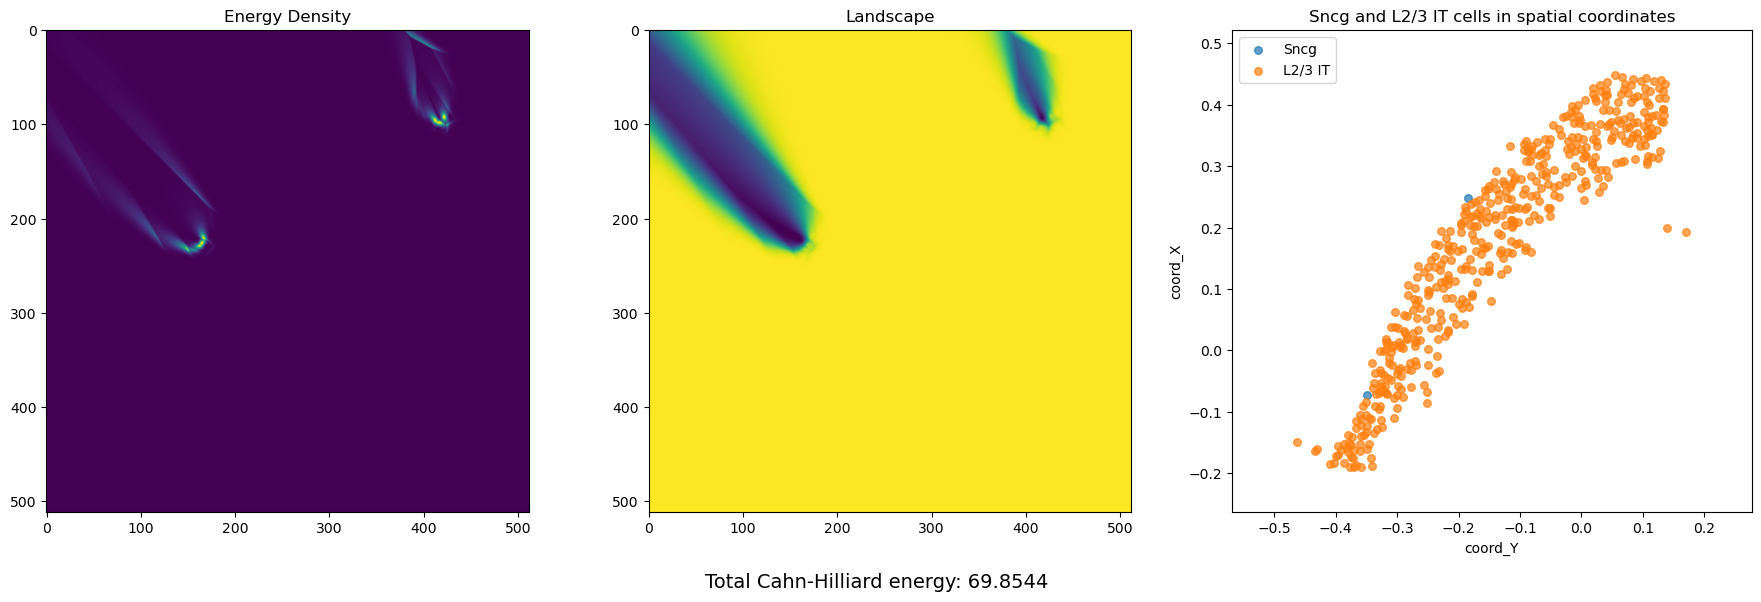

In [142]:
# landscape
cell_10 = 'Astro'
cell_11 = 'Endo'
# let's try
landscape_2_types_scat = build_voronoi_phase_landscape_from_cell_types(df=whole_ground_truth_sample, negative_cell_class_value=cell_10, positive_cell_class_value=cell_11, transition_width=0.01)

# plot 
plot_two_cell_types(whole_ground_truth_sample, cell_10, cell_11, landscape=landscape_2_types_scat, energy=True)

# landscape
cell_12 = 'Sncg'
cell_13 = 'L2/3 IT'
# let's try
landscape_2_types = build_voronoi_phase_landscape_from_cell_types(df=whole_ground_truth_sample, negative_cell_class_value=cell_12, positive_cell_class_value=cell_13, transition_width=0.01)

# plot 
plot_two_cell_types(whole_ground_truth_sample, cell_12, cell_13, landscape=landscape_2_types, energy=True)

In [190]:
# for each pair of cell type, compute the cahn-hilliard energy density and rank these pairs on the highest energy levels
# NORMALIZE BY NUMBER OF CELLS IN EACH PAIR
from cmath import sqrt


pair_energies_n = {}
i_n = 0
already_n = ['Sncg']
for cell_type_value1 in whole_ground_truth_sample["cell_class"].unique():
    already_n.append(cell_type_value1)
    for cell_type_value2 in whole_ground_truth_sample["cell_class"].unique():
        if cell_type_value1 != cell_type_value2 and cell_type_value2 not in already_n:
            # get the number of cells in each cell type
            n_cells_1 = len(whole_ground_truth_sample[whole_ground_truth_sample["cell_class"] == cell_type_value1])
            n_cells_2 = len(whole_ground_truth_sample[whole_ground_truth_sample["cell_class"] == cell_type_value2])
            landscape = build_voronoi_phase_landscape_from_cell_types(df=whole_ground_truth_sample, negative_cell_class_value=cell_type_value1, positive_cell_class_value=cell_type_value2, transition_width=0.01)
            e_landscape = landscape.cahn_hilliard_energy(kappa=1)
            norm = np.log10(max(n_cells_1, 10)) * np.log10(max(n_cells_2, 10))
            pair_energies_n[f"{cell_type_value1} - {cell_type_value2}"] = e_landscape / norm
            i_n += 1
     

print(f"Compared {i} pairs")

Compared 231 pairs


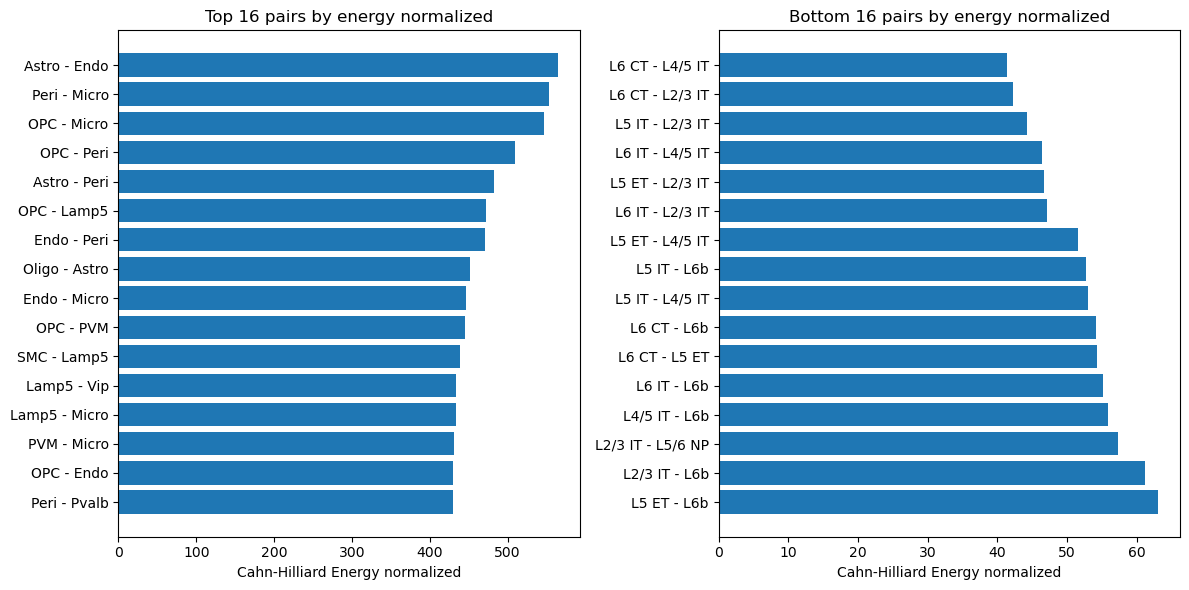

In [191]:
# sort the pairs by energy
sorted_pair_energies_n = sorted(pair_energies_n.items(), key=lambda x: x[1], reverse=True)

# Unpack the sorted pairs into labels (pair names) and their energies
pair_labels_n, energies_n = zip(*sorted_pair_energies_n)

# Plot top ten pairs
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.barh(pair_labels_n[:16][::-1], energies_n[:16][::-1])  # Reverse for most to least at top
plt.title("Top 16 pairs by energy normalized")
plt.xlabel("Cahn-Hilliard Energy normalized")
plt.tight_layout()

# Plot bottom ten pairs
plt.subplot(1, 2, 2)
plt.barh(pair_labels_n[-16:], energies_n[-16:])
plt.title("Bottom 16 pairs by energy normalized")
plt.xlabel("Cahn-Hilliard Energy normalized")
plt.tight_layout()
plt.show()

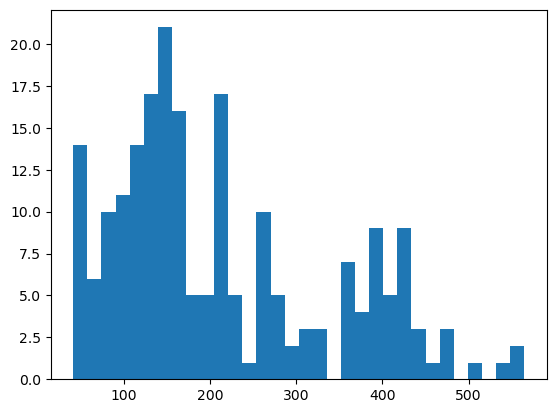

In [198]:
# plot the distribution of energies between the two cell types
plt.hist(pair_energies_n.values(), bins=32)
plt.show()


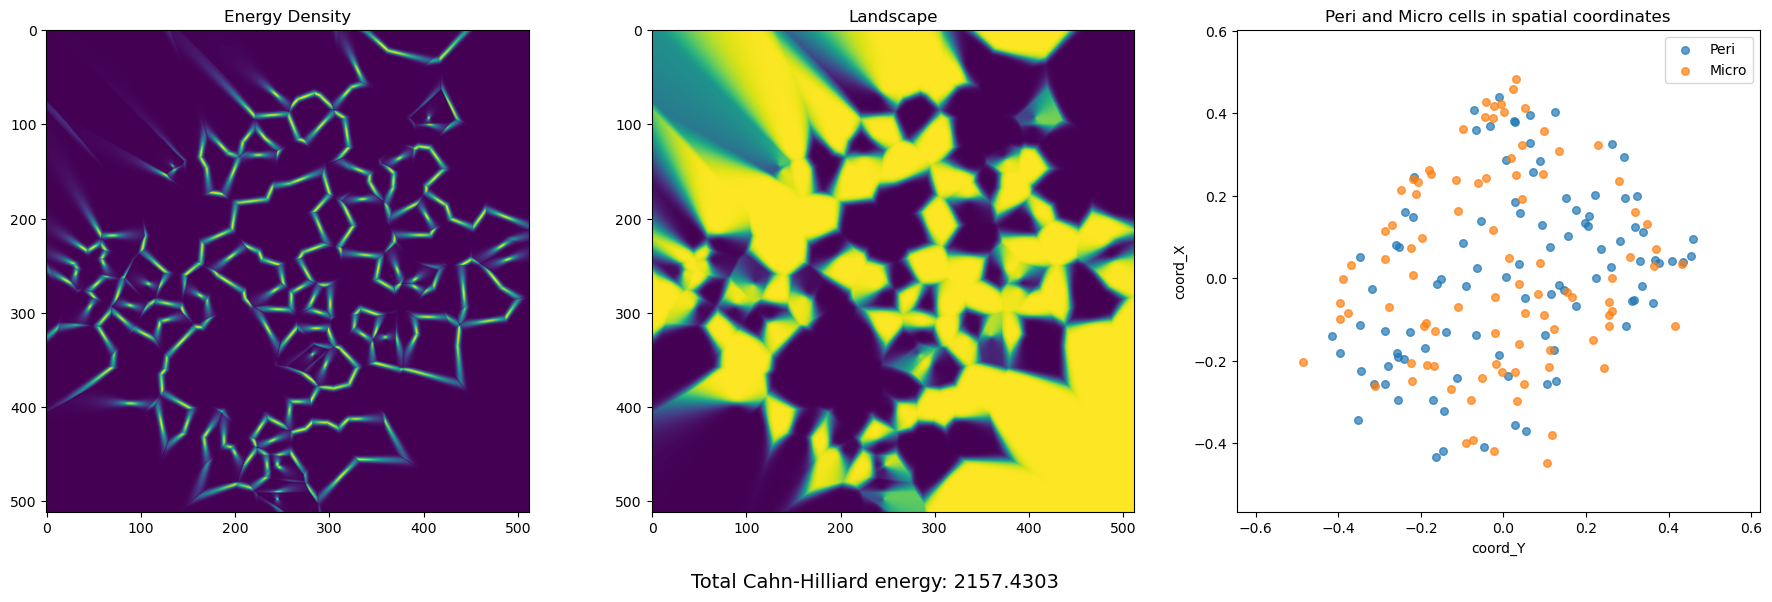

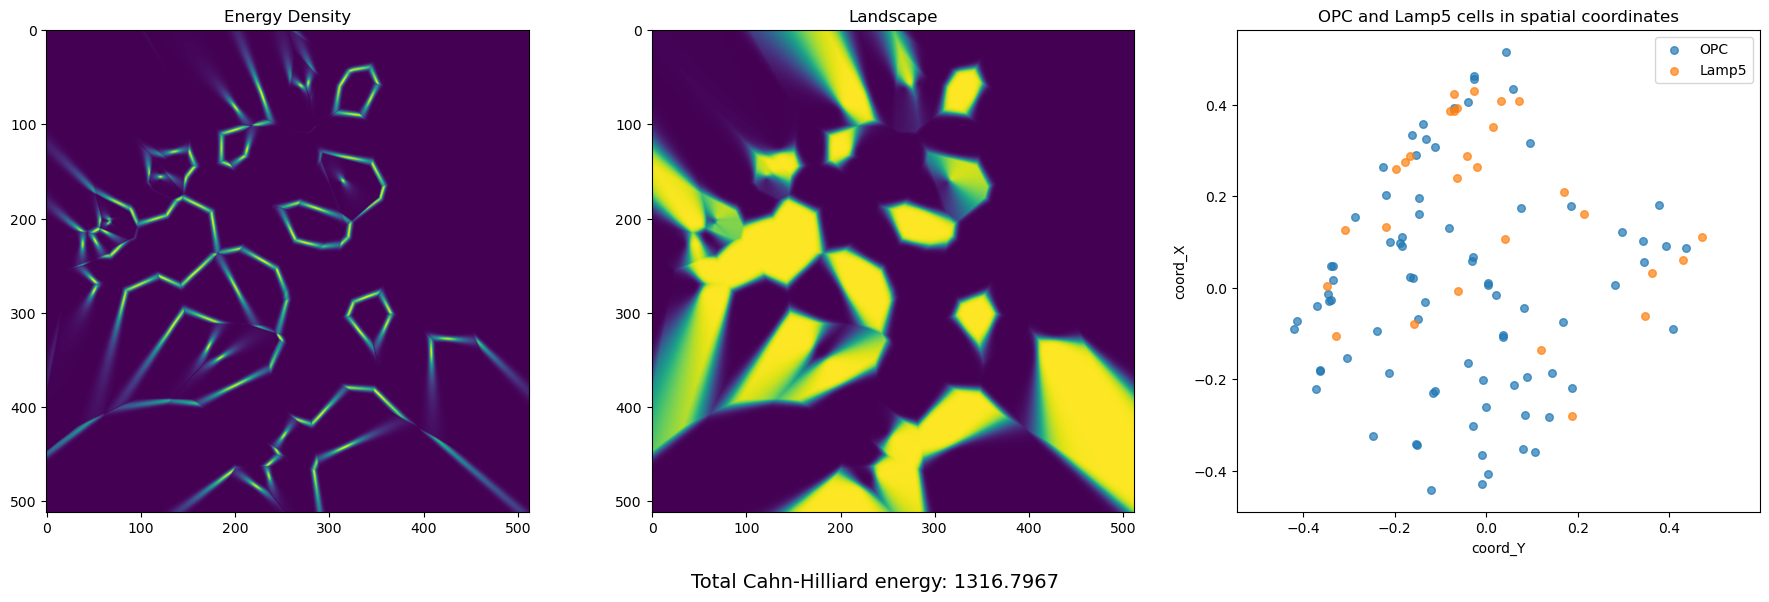

Normalized energies for the last two plots: 471.8070156841331 and 552.8942026074174


In [188]:
#landscape
cell_10 = 'Peri'
cell_11 = 'Micro'
# let's try
landscape_2_types_scat = build_voronoi_phase_landscape_from_cell_types(df=whole_ground_truth_sample, negative_cell_class_value=cell_10, positive_cell_class_value=cell_11, transition_width=0.01)

# plot 
plot_two_cell_types(whole_ground_truth_sample, cell_10, cell_11, landscape=landscape_2_types_scat, energy=True)

# landscape
cell_12 = 'OPC'
cell_13 = 'Lamp5'
# let's try
landscape_2_types = build_voronoi_phase_landscape_from_cell_types(df=whole_ground_truth_sample, negative_cell_class_value=cell_12, positive_cell_class_value=cell_13, transition_width=0.01)

# plot 
plot_two_cell_types(whole_ground_truth_sample, cell_12, cell_13, landscape=landscape_2_types, energy=True)
print(f"Normalized energies for the last two plots: {pair_energies_n[f'{cell_12} - {cell_13}']} and {pair_energies_n[f'{cell_10} - {cell_11}']}")

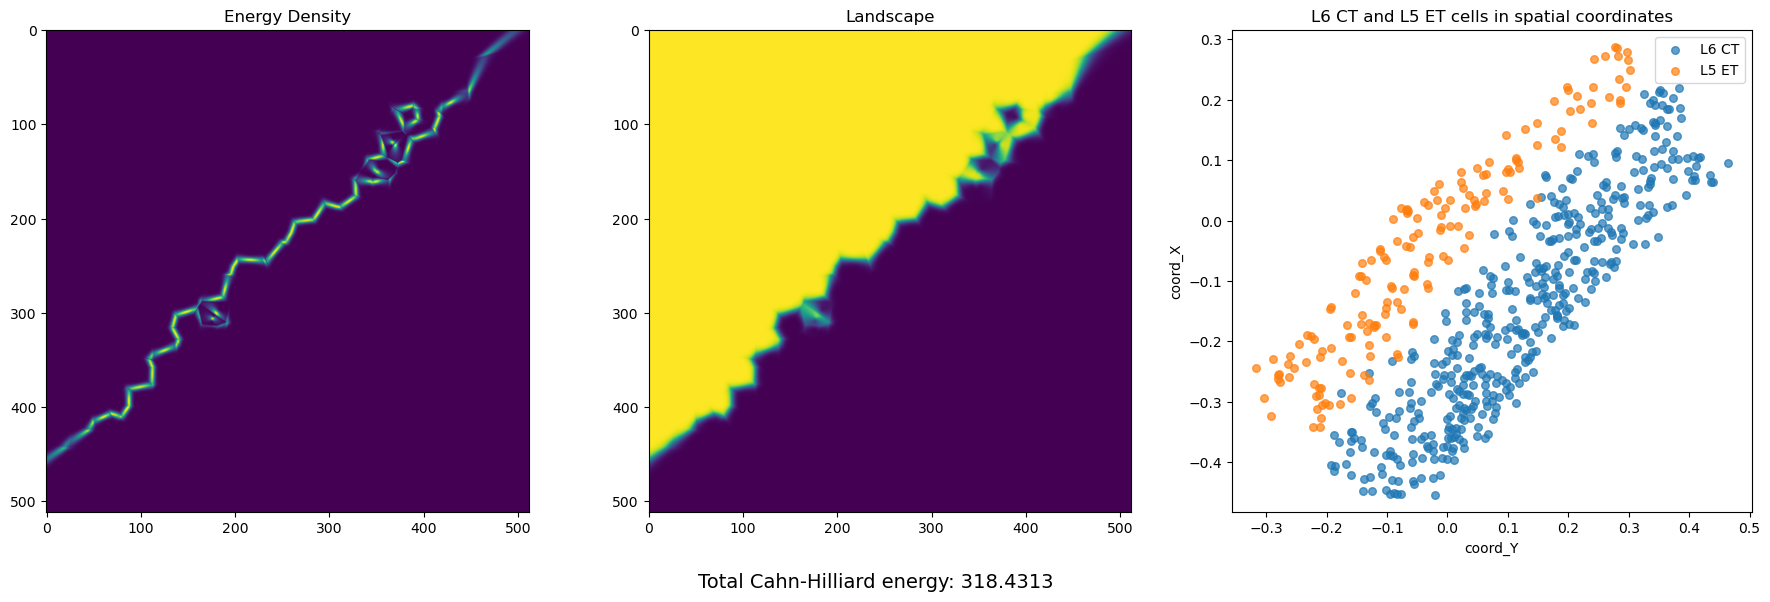

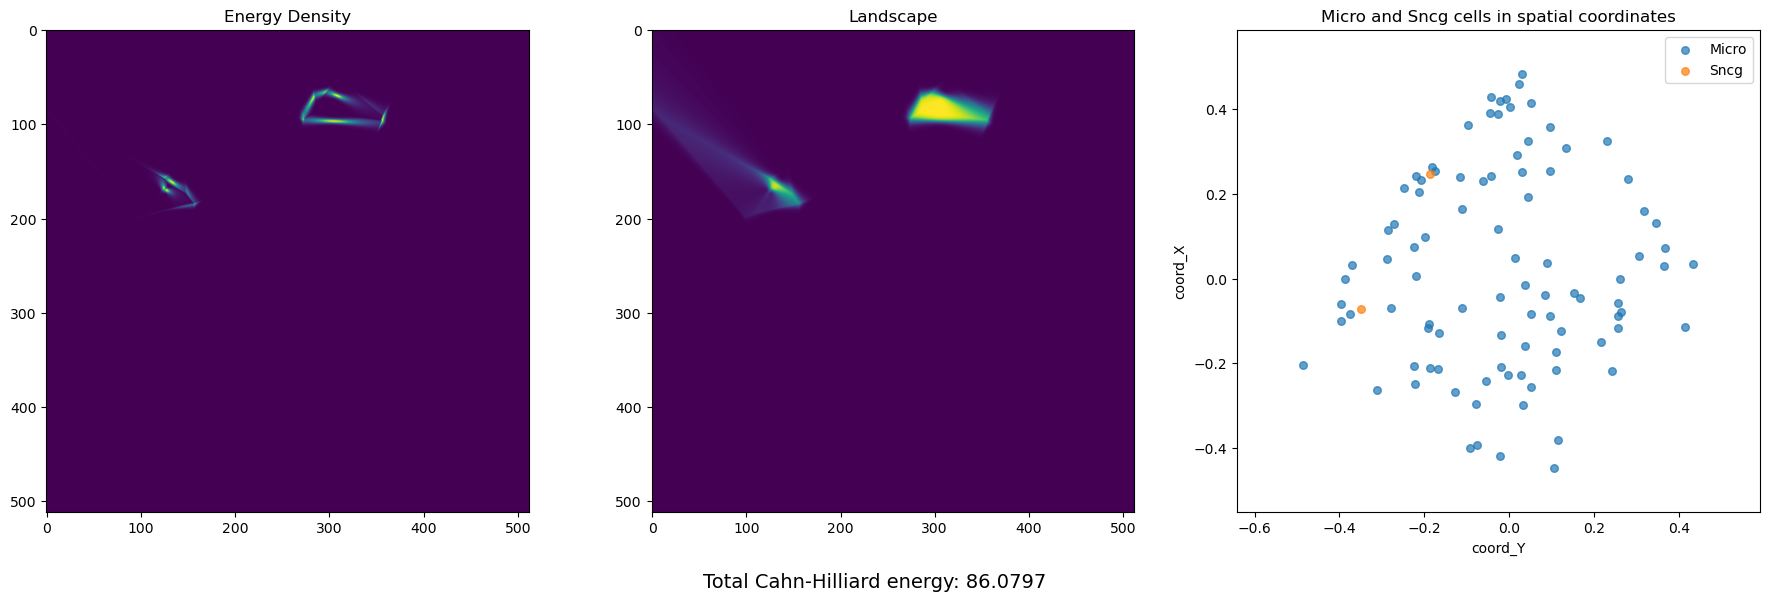

Normalized energies for the last two plots: 43.72897101901789 and 54.31221269957266


In [187]:
#landscape
cell_10 = 'L6 CT'
cell_11 = 'L5 ET'
# let's try
landscape_2_types_scat = build_voronoi_phase_landscape_from_cell_types(df=whole_ground_truth_sample, negative_cell_class_value=cell_10, positive_cell_class_value=cell_11, transition_width=0.01)

# plot 
plot_two_cell_types(whole_ground_truth_sample, cell_10, cell_11, landscape=landscape_2_types_scat, energy=True)

# landscape
cell_12 = 'Micro'
cell_13 = 'Sncg'
# let's try
landscape_2_types = build_voronoi_phase_landscape_from_cell_types(df=whole_ground_truth_sample, negative_cell_class_value=cell_12, positive_cell_class_value=cell_13, transition_width=0.01)

# plot 
plot_two_cell_types(whole_ground_truth_sample, cell_12, cell_13, landscape=landscape_2_types, energy=True)
print(f"Normalized energies for the last two plots: {pair_energies_n[f'{cell_12} - {cell_13}']} and {pair_energies_n[f'{cell_10} - {cell_11}']}")